# Master Thesis - Vignoli Lorenzo

---

## 🐙 Helyx control results

## ⚙️ Import Libraries

In [2]:
# Libraries
import os
import glob
import random
import warnings
import numpy as np # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

import torch # type: ignore
import torch.nn as nn # type: ignore
import torch.optim as optim # type: ignore
from torch.utils.data import Dataset, DataLoader, RandomSampler # type: ignore
import torch.nn.functional as F # type: ignore
import shutil
import plotly.graph_objects as go # type: ignore
from torch.optim.lr_scheduler import LinearLR, ReduceLROnPlateau # type: ignore
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import matplotlib as mpl # type: ignore
from matplotlib import rcParams # type: ignore
from cycler import cycler # type: ignore
import pandas as pd # type: ignore
import sys
from torch.amp import GradScaler, autocast # type: ignore
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.spatial.transform import Rotation as R
from scipy.linalg import solve
from numpy.linalg import lstsq
from scipy.linalg import null_space
import torchvision.models as models
from torchvision.models import mobilenet_v2
from scipy.integrate import cumulative_trapezoid
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from tqdm import tqdm # type: ignore
from matplotlib.ticker import MultipleLocator

# Reconstruction utility
from MULTI_reconstruction_utility import *

# PCC model
from MULTI_jacobians import *
from MULTI_kinematics import *

# Publication-ready plotting setup with TRUE LaTeX rendering
rcParams.update({
   'figure.figsize': (6, 4), 'figure.dpi': 300, 'savefig.dpi': 300,
   'savefig.format': 'pdf', 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
   'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
   'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10,
   'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
   'lines.linewidth': 1.5, 'lines.markersize': 6, 'lines.markeredgewidth': 0.5,
   'axes.linewidth': 1.0, 'axes.spines.top': False, 'axes.spines.right': False,
   'axes.grid': True, 'axes.edgecolor': 'black',  # Fixed: 'edgecolo' -> 'edgecolor'
   'xtick.direction': 'in', 'ytick.direction': 'in',
   'xtick.major.size': 4, 'ytick.major.size': 4,
   'xtick.minor.size': 2, 'ytick.minor.size': 2,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'grid.color': 'gray', 'grid.linestyle': '-', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,  # Fixed: 'grid.colo' -> 'grid.color'
   'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.fancybox': False,
   'legend.edgecolor': 'black', 'legend.facecolor': 'white', 'legend.numpoints': 1,  # Fixed: 'edgecolo' -> 'edgecolor', 'facecolo' -> 'facecolor'
   'text.usetex': True,  # TRUE LaTeX rendering
   'mathtext.default': 'regular',  # Fixed: 'regula' -> 'regular'
   'axes.unicode_minus': False,
   'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'  # Added raw string prefix
})

sns.set_style("whitegrid", {"axes.spines.left": True, "axes.spines.bottom": True,
                          "axes.spines.top": False, "axes.spines.right": False,
                          "grid.color": "0.8", "grid.linestyle": "-", "grid.linewidth": 0.5})
pub_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(pub_colors)
rcParams['axes.prop_cycle'] = cycler('color', pub_colors)  # Fixed: 'colo' -> 'color'

# Ignore warnings
warnings.filterwarnings("ignore")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Angular error function and Workspace

In [3]:
def AngularDistance(pred_euler, target_euler):
        """
        Computes angular distance given predicted and target euler angles ('zyx').
        This is done according to the rotation along the principal axis.
        """

        r_pred = R.from_euler('zyx', pred_euler) 
        r_target = R.from_euler('zyx', target_euler)
        r_error = r_target * r_pred.inv()
        axis_angle = r_error.as_rotvec()
        return np.linalg.norm(axis_angle)

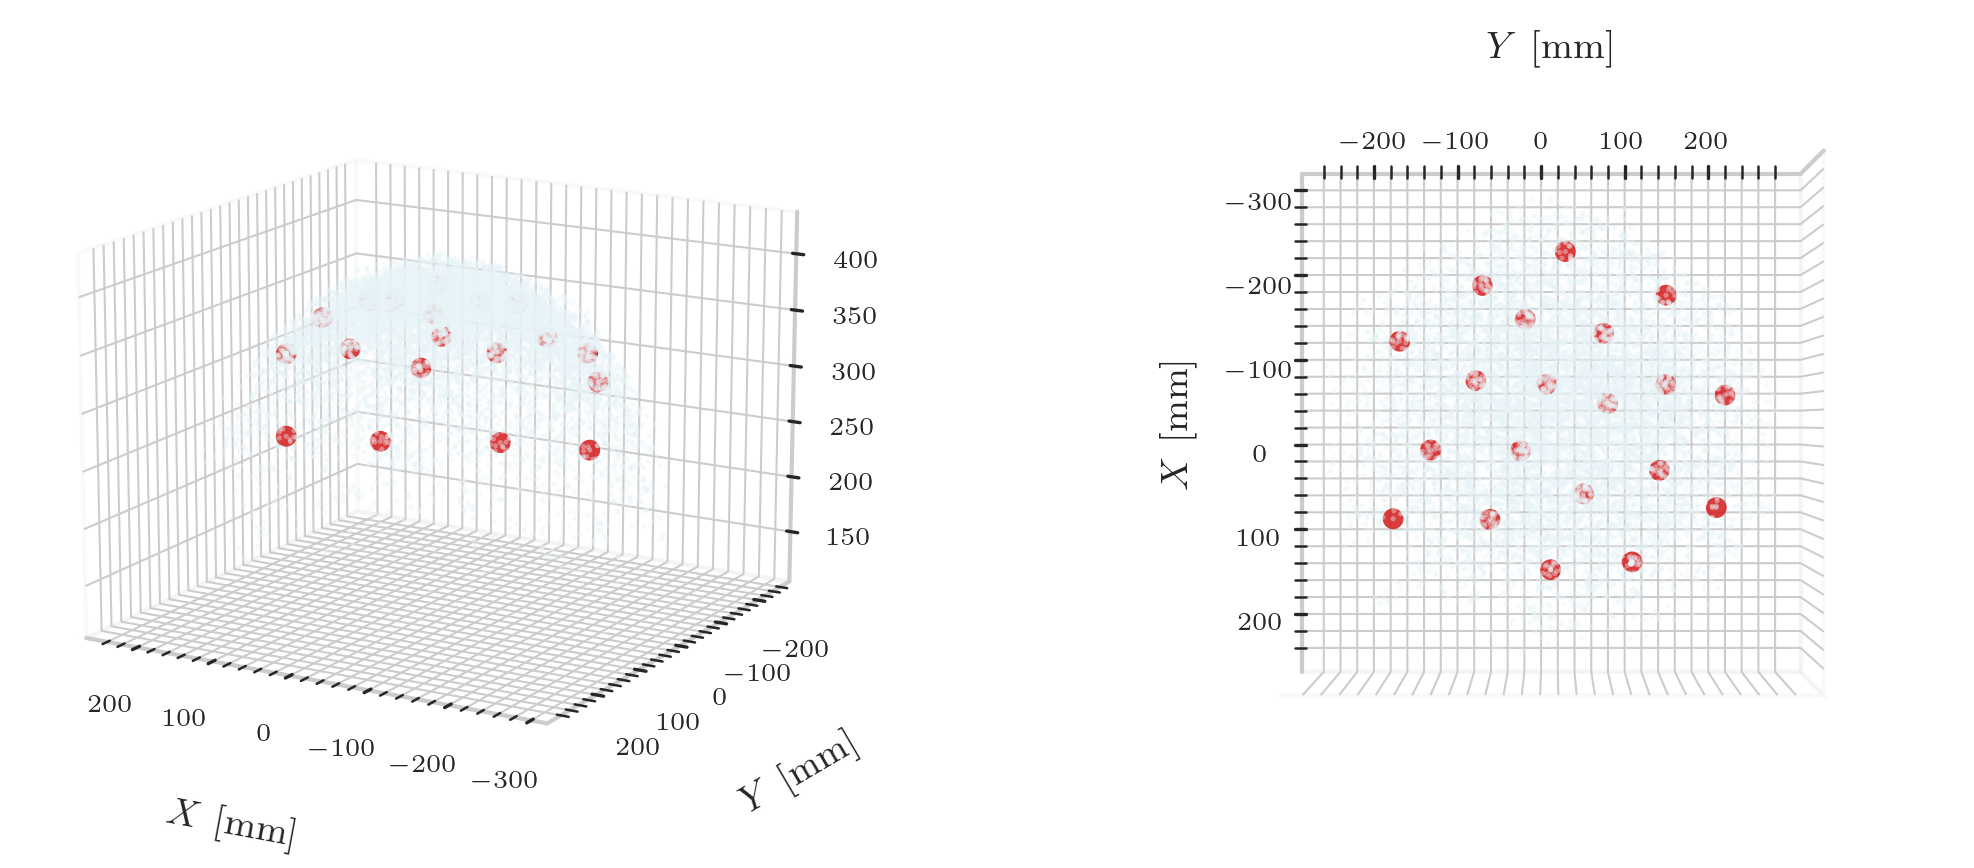

In [4]:
def plot_workspace():
    """
    Plot full workspace and selected control points in 3D from multiple perspectives.
    """
    # Load data
    full_workspace = np.load("Workspace.npz")["pose"]
    control_workspace = np.load("ControlWorkspace.npz")["pose"]

    # Temporarily adjust rcParams for 3D plotting
    original_figsize = rcParams['figure.figsize']
    original_grid = rcParams['axes.grid']
    original_spines_top = rcParams['axes.spines.top']
    original_spines_right = rcParams['axes.spines.right']

    rcParams.update({
        'figure.figsize': (8, 3.5),
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True
    })

    fig = plt.figure(figsize=(8, 3.5))

    # Default 3D view
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(full_workspace[:, 0], full_workspace[:, 1], full_workspace[:, 2], 
                c='#E8F4F8', alpha=0.4, s=1.5, edgecolors='none', rasterized=True)
    ax1.scatter(control_workspace[:, 0], control_workspace[:, 1], control_workspace[:, 2], 
                c='#d62728', s=25, alpha=0.9, edgecolors='none', rasterized=True)
    ax1.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax1.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    # Remove Z-axis label
    ax1.set_zlabel('')
    ax1.tick_params(labelsize=6, pad=1)
    ax1.view_init(elev=15, azim=120)

    # Top view (looking down) - remove Z axis numbers and label
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(full_workspace[:, 0], full_workspace[:, 1], full_workspace[:, 2], 
                c='#E8F4F8', alpha=0.4, s=1.5, edgecolors='none', rasterized=True)
    ax2.scatter(control_workspace[:, 0], control_workspace[:, 1], control_workspace[:, 2], 
                c='#d62728', s=25, alpha=0.9, edgecolors='none', rasterized=True)
    ax2.view_init(elev=90, azim=0)
    ax2.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax2.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=9, labelpad=6)
    ax2.set_zticks([])
    ax2.set_zlabel('')
    ax2.tick_params(labelsize=6, pad=1)

    # Clean 3D panes styling for both subplots
    for ax in [ax1, ax2]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.15, linewidth=0.2)

    # Adjust layout with minimal spacing
    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.05)

    # Restore original rcParams
    rcParams.update({
        'figure.figsize': original_figsize,
        'axes.grid': original_grid,
        'axes.spines.top': original_spines_top,
        'axes.spines.right': original_spines_right
    })

    plt.show()

plot_workspace()


## Workspace plotting functions

Closed Loop Workspace Plotting

In [5]:
def ClosedLoopWorkspacePlotting(name, datadriven):
    """
    Plots the workspace with corresponding position and angular error.
    Now plots position and orientation side-by-side in one figure
    (single view each, both with colorbars), with larger font sizes.
    """
    data = np.load(name)
    target = data["target"]
    mocap = data["mocap"]

    # Compute errors
    target_pos = target[:, :3]
    target_angles = np.rad2deg(target[:, 3:])
    mocap_pos = mocap[:, :3]
    mocap_angles = np.rad2deg(mocap[:, 3:])
    error_pos = np.linalg.norm(target_pos - mocap_pos, axis=1)
    error_angles = np.array([
        AngularDistance(np.deg2rad(target_angles[i]), np.deg2rad(mocap_angles[i]))
        for i in range(len(target_angles))
    ]) * 180/np.pi

    vmax_pos = np.max(error_pos)
    vmax_angles = np.max(error_angles)

    # Truncated colormaps
    trunc_cmap_pos = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_inferno', mpl.cm.get_cmap('inferno')(np.linspace(0, 0.6, 256))
    )
    trunc_cmap_angles = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_viridis', mpl.cm.get_cmap('viridis')(np.linspace(0, 0.6, 256))
    )

    # Temporarily adjust rcParams
    original_figsize = rcParams['figure.figsize']
    original_grid = rcParams['axes.grid']
    original_spines_top = rcParams['axes.spines.top']
    original_spines_right = rcParams['axes.spines.right']
    rcParams.update({
        'figure.figsize': (10, 4),
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True
    })

    # --- Combined Figure (Position + Angular) ---
    fig = plt.figure(figsize=(10, 4))

    # Position error subplot
    ax_pos = fig.add_subplot(1, 2, 1, projection='3d')
    sc_pos = ax_pos.scatter(target_pos[:, 0], target_pos[:, 1], target_pos[:, 2],
                            c=error_pos, cmap=trunc_cmap_pos, s=8,
                            vmin=0, vmax=vmax_pos, alpha=0.8,
                            edgecolors='none', rasterized=True)
    ax_pos.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_pos.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_pos.set_zlabel('')
    ax_pos.view_init(elev=15, azim=120)
    ax_pos.tick_params(labelsize=6, pad=0.5)

    # Ticks
    x_min, x_max = target_pos[:, 0].min(), target_pos[:, 0].max()
    y_min, y_max = target_pos[:, 1].min(), target_pos[:, 1].max()
    x_ticks = np.arange(int(x_min//100)*100, int(x_max//100)*100 + 200, 100)
    y_ticks = np.arange(int(y_min//100)*100, int(y_max//100)*100 + 200, 100)
    ax_pos.set_xticks(x_ticks)
    ax_pos.set_yticks(y_ticks)

    # Style panes
    for ax in [ax_pos]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.5, linewidth=1)

    # Position colorbar
    cbar_ax_pos = fig.add_axes([0.46, 0.3, 0.015, 0.4])
    cbar_pos = fig.colorbar(sc_pos, cax=cbar_ax_pos)
    cbar_pos.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', fontsize=14, labelpad=18)
    cbar_pos.ax.tick_params(labelsize=6)

    # Angular error subplot
    ax_ang = fig.add_subplot(1, 2, 2, projection='3d')
    sc_ang = ax_ang.scatter(target_pos[:, 0], target_pos[:, 1], target_pos[:, 2],
                            c=error_angles, cmap=trunc_cmap_angles, s=8,
                            vmin=0, vmax=vmax_angles, alpha=0.8,
                            edgecolors='none', rasterized=True)
    ax_ang.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_ang.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_ang.set_zlabel('')
    ax_ang.view_init(elev=15, azim=120)
    ax_ang.tick_params(labelsize=6, pad=0.5)
    ax_ang.set_xticks(x_ticks)
    ax_ang.set_yticks(y_ticks)

    for ax in [ax_ang]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.5, linewidth=1)

    # Angular colorbar
    cbar_ax_ang = fig.add_axes([0.92, 0.3, 0.015, 0.4])
    cbar_ang = fig.colorbar(sc_ang, cax=cbar_ax_ang)
    cbar_ang.set_label(r'$\mathrm{Error}~[^\circ]$', fontsize=14, labelpad=18)
    cbar_ang.ax.tick_params(labelsize=6)

    plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3)
    plt.show()

    # Print summaries
    print(f"\n--- Position Error Summary (Target vs Mocap) - {len(error_pos)} data ---")
    print(f"Mean Error: {np.mean(error_pos):.2f} mm")
    print(f"Standard Deviation: {np.std(error_pos):.2f} mm")

    print(f"\n--- Angular Error Summary (Target vs Mocap) ---")
    print(f"Mean Error: {np.mean(error_angles):.2f} °")
    print(f"Standard Deviation: {np.std(error_angles):.2f} °")

    # Restore rcParams
    rcParams.update({
        'figure.figsize': original_figsize,
        'axes.grid': original_grid,
        'axes.spines.top': original_spines_top,
        'axes.spines.right': original_spines_right
    })


Open Loop Workspace Plotting

In [6]:
def OpenLoopWorkspacePlotting(name, datadriven):
    """
    Plots the workspace with corresponding position and angular error.
    Now plots position and orientation side-by-side in one figure
    (single view each, both with colorbars), with larger font sizes.
    """
    data = np.load(name)
    target = data["target"]
    mocap = data["mocap"]

    # Compute errors
    target_pos = target[:, :3]
    target_angles = np.rad2deg(target[:, 3:])
    mocap_pos = mocap[:, :3]
    mocap_angles = np.rad2deg(mocap[:, 3:])
    error_pos = np.linalg.norm(target_pos - mocap_pos, axis=1)
    error_angles = np.array([
        AngularDistance(np.deg2rad(target_angles[i]), np.deg2rad(mocap_angles[i]))
        for i in range(len(target_angles))
    ]) * 180/np.pi

    vmax_pos = np.max(error_pos)
    vmax_angles = np.max(error_angles)

    # Truncated colormaps
    trunc_cmap_pos = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_inferno', mpl.cm.get_cmap('inferno')(np.linspace(0, 0.6, 256))
    )
    trunc_cmap_angles = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_viridis', mpl.cm.get_cmap('viridis')(np.linspace(0, 0.6, 256))
    )

    # Temporarily adjust rcParams (unchanged)
    original_figsize = rcParams['figure.figsize']
    original_grid = rcParams['axes.grid']
    original_spines_top = rcParams['axes.spines.top']
    original_spines_right = rcParams['axes.spines.right']
    rcParams.update({
        'figure.figsize': (8, 3.5),
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True
    })

    # ---- Combined figure: Position (left) + Angular (right) ----
    fig = plt.figure(figsize=(8, 3.5))

    # Common ticks
    x_min, x_max = target_pos[:, 0].min(), target_pos[:, 0].max()
    y_min, y_max = target_pos[:, 1].min(), target_pos[:, 1].max()
    x_ticks = np.arange(int(x_min//100)*100, int(x_max//100)*100 + 200, 100)
    y_ticks = np.arange(int(y_min//100)*100, int(y_max//100)*100 + 200, 100)

    # Position error (single 3D view)
    ax_pos = fig.add_subplot(1, 2, 1, projection='3d')
    sc_pos = ax_pos.scatter(target_pos[:, 0], target_pos[:, 1], target_pos[:, 2],
                            c=error_pos, cmap=trunc_cmap_pos, s=8, vmin=0, vmax=vmax_pos,
                            alpha=0.8, edgecolors='none', rasterized=True)
    ax_pos.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_pos.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_pos.set_zlabel('')
    ax_pos.view_init(elev=15, azim=120)
    ax_pos.tick_params(labelsize=6, pad=0.5)
    ax_pos.set_xticks(x_ticks)
    ax_pos.set_yticks(y_ticks)

    # Angular error (single 3D view)
    ax_ang = fig.add_subplot(1, 2, 2, projection='3d')
    sc_ang = ax_ang.scatter(target_pos[:, 0], target_pos[:, 1], target_pos[:, 2],
                            c=error_angles, cmap=trunc_cmap_angles, s=8, vmin=0, vmax=vmax_angles,
                            alpha=0.8, edgecolors='none', rasterized=True)
    ax_ang.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_ang.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=10, labelpad=7)
    ax_ang.set_zlabel('')
    ax_ang.view_init(elev=15, azim=120)
    ax_ang.tick_params(labelsize=6, pad=0.5)
    ax_ang.set_xticks(x_ticks)
    ax_ang.set_yticks(y_ticks)

    # 3D panes styling (unchanged)
    for ax in [ax_pos, ax_ang]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.5, linewidth=1)

    # Two colorbars
    cbar_ax_pos = fig.add_axes([0.46, 0.2, 0.015, 0.6])
    cbar_pos = fig.colorbar(sc_pos, cax=cbar_ax_pos)
    cbar_pos.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', fontsize=14, labelpad=18)
    cbar_pos.ax.tick_params(labelsize=6)

    cbar_ax_ang = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    cbar_ang = fig.colorbar(sc_ang, cax=cbar_ax_ang)
    cbar_ang.set_label(r'$\mathrm{Error}~[^\circ]$', fontsize=14, labelpad=18)
    cbar_ang.ax.tick_params(labelsize=6)

    plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3)
    plt.show()

    # Summaries (unchanged)
    print(f"\n--- Position Error Summary (Target vs Mocap) - {len(error_pos)} data ---")
    print(f"Mean Error: {np.mean(error_pos):.2f} mm")
    print(f"Standard Deviation: {np.std(error_pos):.2f} mm")

    print(f"\n--- Angular Error Summary (Target vs Mocap) ---")
    print(f"Mean Error: {np.mean(error_angles):.2f} °")
    print(f"Standard Deviation: {np.std(error_angles):.2f} °")

    # Restore rcParams (unchanged)
    rcParams.update({
        'figure.figsize': original_figsize,
        'axes.grid': original_grid,
        'axes.spines.top': original_spines_top,
        'axes.spines.right': original_spines_right
    })

    ax_ang.set_zlabel('')
    ax_ang.view_init(elev=15, azim=120)
    ax_ang.tick_params(labelsize=6, pad=0.5)
    ax_ang.set_xticks(x_ticks)
    ax_ang.set_yticks(y_ticks)

    # 3D panes styling (unchanged)
    for ax in [ax_pos, ax_ang]:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(True, alpha=0.5, linewidth=1)

    # Two colorbars
    cbar_ax_pos = fig.add_axes([0.46, 0.2, 0.015, 0.6])
    cbar_pos = fig.colorbar(sc_pos, cax=cbar_ax_pos)
    cbar_pos.set_label(r'$\mathrm{Error}~[\mathrm{mm}]$', fontsize=14, labelpad=18)
    cbar_pos.ax.tick_params(labelsize=6)

    cbar_ax_ang = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    cbar_ang = fig.colorbar(sc_ang, cax=cbar_ax_ang)
    cbar_ang.set_label(r'$\mathrm{Error}~[^\circ]$', fontsize=14, labelpad=18)
    cbar_ang.ax.tick_params(labelsize=6)

    plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3)
    plt.show()

    # Summaries (unchanged)
    print(f"\n--- Position Error Summary (Target vs Mocap) - {len(error_pos)} data ---")
    print(f"Mean Error: {np.mean(error_pos):.2f} mm")
    print(f"Standard Deviation: {np.std(error_pos):.2f} mm")

    print(f"\n--- Angular Error Summary (Target vs Mocap) ---")
    print(f"Mean Error: {np.mean(error_angles):.2f} °")
    print(f"Standard Deviation: {np.std(error_angles):.2f} °")

    # Restore rcParams (unchanged)
    rcParams.update({
        'figure.figsize': original_figsize,
        'axes.grid': original_grid,
        'axes.spines.top': original_spines_top,
        'axes.spines.right': original_spines_right
    })


Closed Loop Polygon Plotting

In [7]:
available_configs = [
    (30, 80, 380),
    (30, 120, 350),
]

In [8]:
def ClosedLoopPolygonPlotting(method, n_sides, available_configs=available_configs, w_string=""):
    configs = [config for config in available_configs if config[0] == n_sides]
    if not configs:
        print(f"No configurations found for {n_sides} sides")
        return
    
    _, axes = plt.subplots(1, 2, figsize=(12, 6))  # scaled up figure
    ax_xy, ax_zx = axes

    # 🔑 forza stessa larghezza fisica dei due subplot
    ax_xy.set_box_aspect(1)
    ax_zx.set_box_aspect(1)
    
    colors = ["#1f77b4", "#ff7f0e"]
    theoretical_color = "#2c3e50"
    
    for i, (sides, radius, height) in enumerate(configs):
        if w_string:
            base_path_dd = f"PolygonDatadriven_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonJacobian_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
        else:
            base_path_dd = f"PolygonDatadriven_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonJacobian_{sides}sides_{radius}mm_{height}mm.npz"
        filename = base_path_dd if method == "datadriven" else base_path_jac
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
        
        data = np.load(filename)
        target = data["target"]
        mocap = data["mocap"]
        polygon_vertices = target[:, :3]
        
        polygon_vertices_closed = np.vstack([polygon_vertices, polygon_vertices[0]])
        mocap_closed = np.vstack([mocap, mocap[0]])
        
        mocap_color = colors[i % len(colors)]
        
        ax_xy.plot(polygon_vertices_closed[:, 0], polygon_vertices_closed[:, 1], 
                   '--', color=theoretical_color, linewidth=3.0, alpha=0.8)
        ax_xy.plot(mocap_closed[:, 0], mocap_closed[:, 1], 
                   '-', color=mocap_color, linewidth=2.5, alpha=0.9)
        
        ax_zx.plot(polygon_vertices_closed[:, 0], polygon_vertices_closed[:, 2], 
                   '--', color=theoretical_color, linewidth=3.0, alpha=0.8)
        ax_zx.plot(mocap_closed[:, 0], mocap_closed[:, 2], 
                   '-', color=mocap_color, linewidth=2.5, alpha=0.9)
    
    ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=26)
    ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=26)
    ax_xy.set_aspect("equal")
    ax_xy.grid(True, alpha=0.3, linewidth=1.0)
    ax_xy.tick_params(labelsize=24)
    
    ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=26)
    ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=26)
    ax_zx.grid(True, alpha=0.3, linewidth=1.0)
    ax_zx.tick_params(labelsize=24)
    ax_zx.set_ylim([0, 450])
    
    plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
    plt.show()
    
    shape_name = {3: "Triangle", 4: "Square", 6: "Hexagon", 30: "Circle"}
    shape = shape_name.get(n_sides, f'{n_sides}-sided polygon')
    title_suffix = f" + {w_string}" if w_string else ""
    
    print(f"Plotted {len(configs)} configurations for {shape} - {method} control{title_suffix}")
    print(f"\n--- Angular Error Analysis for {shape} - {method} control{title_suffix} ---")
    
    for i, (sides, radius, height) in enumerate(configs):
        if w_string:
            base_path_dd = f"PolygonDatadriven_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonJacobian_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
        else:
            base_path_dd = f"PolygonDatadriven_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonJacobian_{sides}sides_{radius}mm_{height}mm.npz"
        filename = base_path_dd if method == "datadriven" else base_path_jac
    
        if not os.path.exists(filename):
            continue
        
        data = np.load(filename)
        target = data["target"]
        mocap = data["mocap"]
    
        angular_errors = np.array([
            AngularDistance(target[j, 3:], mocap[j, 3:]) 
            for j in range(len(target))
        ]) * 180/np.pi
    
        config_label = f"r={radius}mm, h={height}mm"
        print(f"{config_label}: {np.mean(angular_errors):.2f} ± {np.std(angular_errors):.2f} $^\\circ$")


In [9]:
def OpenLoopPolygonPlotting(method, n_sides, available_configs=available_configs, w_string=""):
    configs = [config for config in available_configs if config[0] == n_sides]
    if not configs:
        print(f"No configurations found for {n_sides} sides")
        return
    
    _, axes = plt.subplots(1, 2, figsize=(12, 6))  # larger figure
    ax_xy, ax_zx = axes

    # 🔑 forza stessa larghezza fisica per entrambi i subplot
    ax_xy.set_box_aspect(1)
    ax_zx.set_box_aspect(1)
    
    colors = ["#1f77b4", "#ff7f0e"]
    theoretical_color = "#2c3e50"
    
    for i, (sides, radius, height) in enumerate(configs):
        if w_string:
            base_path_dd = f"PolygonOpenLoopDatadriven_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonOpenLoopJacobian_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
        else:
            base_path_dd = f"PolygonOpenLoopDatadriven_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonOpenLoopJacobian_{sides}sides_{radius}mm_{height}mm.npz"
        filename = base_path_dd if method == "datadriven" else base_path_jac
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
        
        data = np.load(filename)
        target = data["target"]
        mocap = data["mocap"]
        polygon_vertices = target[:, :3]
        
        polygon_vertices_closed = np.vstack([polygon_vertices, polygon_vertices[0]])
        mocap_closed = np.vstack([mocap, mocap[0]])
        
        mocap_color = colors[i % len(colors)]
        
        ax_xy.plot(polygon_vertices_closed[:, 0], polygon_vertices_closed[:, 1], 
                   '--', color=theoretical_color, linewidth=3.0, alpha=0.8)
        ax_xy.plot(mocap_closed[:, 0], mocap_closed[:, 1], 
                   '-', color=mocap_color, linewidth=2.5, alpha=0.9)
        
        ax_zx.plot(polygon_vertices_closed[:, 0], polygon_vertices_closed[:, 2], 
                   '--', color=theoretical_color, linewidth=3.0, alpha=0.8)
        ax_zx.plot(mocap_closed[:, 0], mocap_closed[:, 2], 
                   '-', color=mocap_color, linewidth=2.5, alpha=0.9)
    
    ax_xy.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=26)
    ax_xy.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=26)
    ax_xy.set_aspect("equal")
    ax_xy.grid(True, alpha=0.3, linewidth=1.0)
    ax_xy.tick_params(labelsize=24)
    
    ax_zx.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=26)
    ax_zx.set_ylabel(r'$Z~[\mathrm{mm}]$', fontsize=26)
    ax_zx.grid(True, alpha=0.3, linewidth=1.0)
    ax_zx.tick_params(labelsize=24)
    ax_zx.set_ylim([0, 450])
    
    plt.subplots_adjust(left=0.1, right=0.95, wspace=0.3)
    plt.show()
    
    shape_name = {3: "Triangle", 4: "Square", 6: "Hexagon", 30: "Circle"}
    shape = shape_name.get(n_sides, f'{n_sides}-sided polygon')
    title_suffix = f" + {w_string}" if w_string else ""
    
    print(f"Plotted {len(configs)} configurations for {shape} - {method} control{title_suffix}")
    print(f"\n--- Angular Error Analysis for {shape} - {method} control{title_suffix} - Open Loop ---")
    
    for i, (sides, radius, height) in enumerate(configs):
        if w_string:
            base_path_dd = f"PolygonOpenLoopDatadriven_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonOpenLoopJacobian_{w_string}_{sides}sides_{radius}mm_{height}mm.npz"
        else:
            base_path_dd = f"PolygonOpenLoopDatadriven_{sides}sides_{radius}mm_{height}mm.npz"
            base_path_jac = f"PolygonOpenLoopJacobian_{sides}sides_{radius}mm_{height}mm.npz"
        filename = base_path_dd if method == "datadriven" else base_path_jac
    
        if not os.path.exists(filename):
            continue
        
        data = np.load(filename)
        target = data["target"]
        mocap = data["mocap"]
    
        angular_errors = np.array([
            AngularDistance(target[j, 3:], mocap[j, 3:]) 
            for j in range(len(target))
        ]) * 180/np.pi
    
        config_label = f"r={radius}mm, h={height}mm"
        print(f"{config_label}: {np.mean(angular_errors):.2f} ± {np.std(angular_errors):.2f} $^\\circ$")


## Workspace comparison - CL

In [10]:
def ComparativeWorkspacePlotting(jacobian_file, datadriven_file):
    data_jac = np.load(jacobian_file)
    data_dd = np.load(datadriven_file)
    
    target_jac = data_jac["target"]
    mocap_jac = data_jac["mocap"]
    target_dd = data_dd["target"]
    mocap_dd = data_dd["mocap"]

    target_pos_jac = target_jac[:, :3]
    mocap_pos_jac = mocap_jac[:, :3]
    target_pos_dd = target_dd[:, :3]
    mocap_pos_dd = mocap_dd[:, :3]
    
    error_pos_jac = np.linalg.norm(target_pos_jac - mocap_pos_jac, axis=1)
    error_pos_dd = np.linalg.norm(target_pos_dd - mocap_pos_dd, axis=1)

    target_angles_jac = np.rad2deg(target_jac[:, 3:])
    mocap_angles_jac = np.rad2deg(mocap_jac[:, 3:])
    target_angles_dd = np.rad2deg(target_dd[:, 3:])
    mocap_angles_dd = np.rad2deg(mocap_dd[:, 3:])
    
    error_angles_jac = np.array([
        AngularDistance(np.deg2rad(target_angles_jac[i]), np.deg2rad(mocap_angles_jac[i]))
        for i in range(len(target_angles_jac))
    ]) * 180/np.pi
    
    error_angles_dd = np.array([
        AngularDistance(np.deg2rad(target_angles_dd[i]), np.deg2rad(mocap_angles_dd[i]))
        for i in range(len(target_angles_dd))
    ]) * 180/np.pi

    vmax_pos = max(np.max(error_pos_jac), np.max(error_pos_dd))
    vmax_angles = max(np.max(error_angles_jac), np.max(error_angles_dd))

    trunc_cmap_viridis = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_viridis', mpl.cm.get_cmap('viridis')(np.linspace(0, 0.6, 256))
    )
    trunc_cmap_plasma = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc_plasma', mpl.cm.get_cmap('plasma')(np.linspace(0, 0.6, 256))
    )

    original_params = rcParams.copy()
    rcParams.update({
        'font.family': 'serif',
        'axes.linewidth': 1.2,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 8,
        'ytick.major.size': 8
    })

    fig = plt.figure(figsize=(10, 9))

    def setup_ax(ax, scatter):
        ax.set_xlabel(r'$X~[\mathrm{mm}]$', fontsize=22, labelpad=8)
        ax.set_ylabel(r'$Y~[\mathrm{mm}]$', fontsize=22, labelpad=8)
        ax.set_zlabel('')
        ax.view_init(elev=15, azim=120)
        ax.tick_params(labelsize=16, pad=4, width=1.2)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('#cccccc')
        ax.yaxis.pane.set_edgecolor('#cccccc')
        ax.zaxis.pane.set_edgecolor('#cccccc')
        ax.xaxis.pane.set_alpha(0.1)
        ax.yaxis.pane.set_alpha(0.1)
        ax.zaxis.pane.set_alpha(0.1)
        ax.grid(False)
        return scatter

    ax1_pos = fig.add_subplot(2, 2, 1, projection='3d')
    sc_pos_jac = setup_ax(ax1_pos, ax1_pos.scatter(
        target_pos_jac[:, 0], target_pos_jac[:, 1], target_pos_jac[:, 2],
        c=error_pos_jac, cmap=trunc_cmap_viridis, s=25, vmin=0, vmax=vmax_pos,
        alpha=0.85, edgecolors='none', rasterized=True))

    ax2_pos = fig.add_subplot(2, 2, 2, projection='3d')
    setup_ax(ax2_pos, ax2_pos.scatter(
        target_pos_dd[:, 0], target_pos_dd[:, 1], target_pos_dd[:, 2],
        c=error_pos_dd, cmap=trunc_cmap_viridis, s=25, vmin=0, vmax=vmax_pos,
        alpha=0.85, edgecolors='none', rasterized=True))

    ax1_ang = fig.add_subplot(2, 2, 3, projection='3d')
    sc_ang_jac = setup_ax(ax1_ang, ax1_ang.scatter(
        target_pos_jac[:, 0], target_pos_jac[:, 1], target_pos_jac[:, 2],
        c=error_angles_jac, cmap=trunc_cmap_plasma, s=25, vmin=0, vmax=vmax_angles,
        alpha=0.85, edgecolors='none', rasterized=True))

    ax2_ang = fig.add_subplot(2, 2, 4, projection='3d')
    setup_ax(ax2_ang, ax2_ang.scatter(
        target_pos_dd[:, 0], target_pos_dd[:, 1], target_pos_dd[:, 2],
        c=error_angles_dd, cmap=trunc_cmap_plasma, s=25, vmin=0, vmax=vmax_angles,
        alpha=0.85, edgecolors='none', rasterized=True))

    x_min = min(target_pos_jac[:, 0].min(), target_pos_dd[:, 0].min())
    x_max = max(target_pos_jac[:, 0].max(), target_pos_dd[:, 0].max())
    y_min = min(target_pos_jac[:, 1].min(), target_pos_dd[:, 1].min())
    y_max = max(target_pos_jac[:, 1].max(), target_pos_dd[:, 1].max())
    z_min = min(target_pos_jac[:, 2].min(), target_pos_dd[:, 2].min())
    z_max = max(target_pos_jac[:, 2].max(), target_pos_dd[:, 2].max())
    
    x_ticks = np.arange(int(x_min//200)*200, int(x_max//200)*200 + 400, 200)
    y_ticks = np.arange(int(y_min//200)*200, int(y_max//200)*200 + 400, 200)
    z_ticks = np.arange(int(z_min//50)*50, int(z_max//50)*50 + 100, 50)

    x_ticks = [t for t in x_ticks if abs(t) != 400]
    y_ticks = [t for t in y_ticks if abs(t) != 400]

    for ax in [ax1_pos, ax2_pos, ax1_ang, ax2_ang]:
        ax.set_xticks(x_ticks)
        ax.set_yticks(y_ticks)
        ax.set_zticks(z_ticks)

    cbar_ax_pos = fig.add_axes([0.92, 0.548, 0.02, 0.352])
    cbar_pos = fig.colorbar(sc_pos_jac, cax=cbar_ax_pos)
    cbar_pos.ax.tick_params(labelsize=16, width=1.2)

    cbar_ax_ang = fig.add_axes([0.92, 0.098, 0.02, 0.352])
    cbar_ang = fig.colorbar(sc_ang_jac, cax=cbar_ax_ang)
    cbar_ang.ax.tick_params(labelsize=16, width=1.2)

    plt.subplots_adjust(left=0.07, right=0.9, hspace=0.2, wspace=0.15)
    plt.show()

    print(f"\n--- Position Error Summary - {len(error_pos_jac)} data points ---")
    print(f"Jacobian - Mean: {np.mean(error_pos_jac):.2f} mm, Std: {np.std(error_pos_jac):.2f} mm")
    print(f"Data-driven - Mean: {np.mean(error_pos_dd):.2f} mm, Std: {np.std(error_pos_dd):.2f} mm")
    
    print(f"\n--- Angular Error Summary ---")
    print(f"Jacobian - Mean: {np.mean(error_angles_jac):.2f}°, Std: {np.std(error_angles_jac):.2f}°")
    print(f"Data-driven - Mean: {np.mean(error_angles_dd):.2f}°, Std: {np.std(error_angles_dd):.2f}°")

    rcParams.update(original_params)


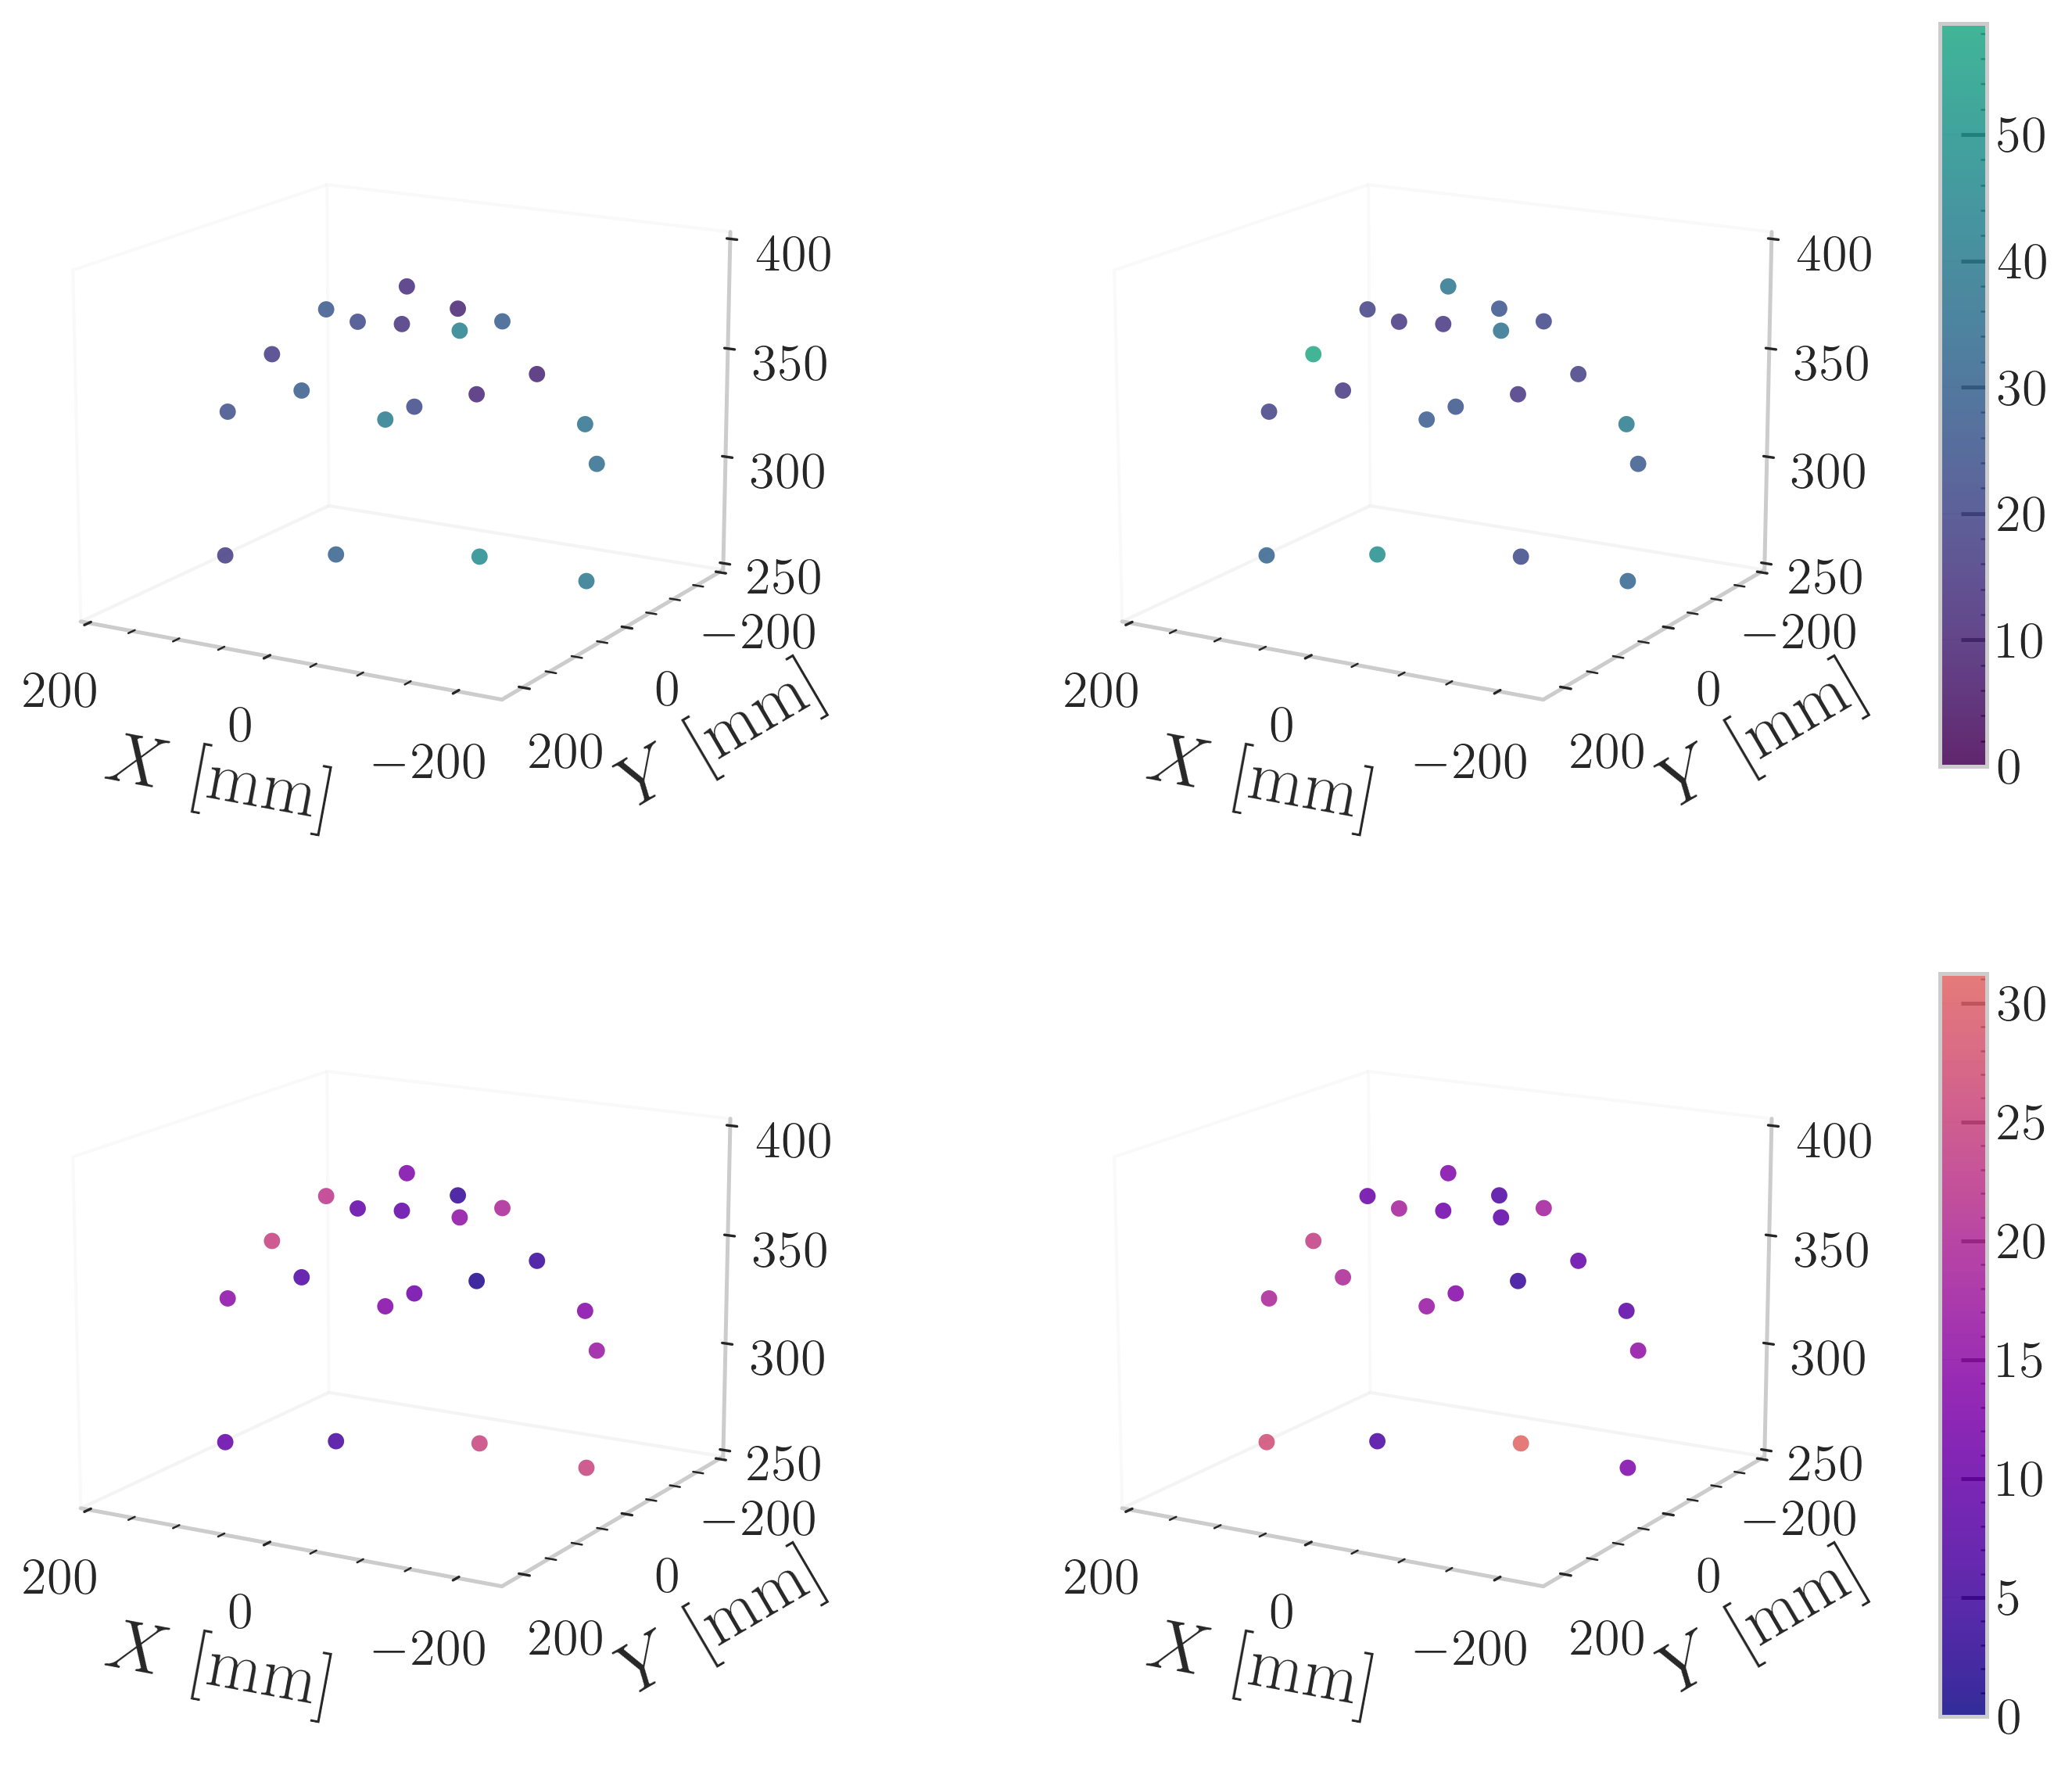


--- Position Error Summary - 20 data points ---
Jacobian - Mean: 25.32 mm, Std: 11.42 mm
Data-driven - Mean: 27.42 mm, Std: 11.60 mm

--- Angular Error Summary ---
Jacobian - Mean: 13.21°, Std: 7.10°
Data-driven - Mean: 14.72°, Std: 7.00°


In [11]:
ComparativeWorkspacePlotting("ControlWorkspaceJacobian.npz", "ControlWorkspaceDatadriven.npz")

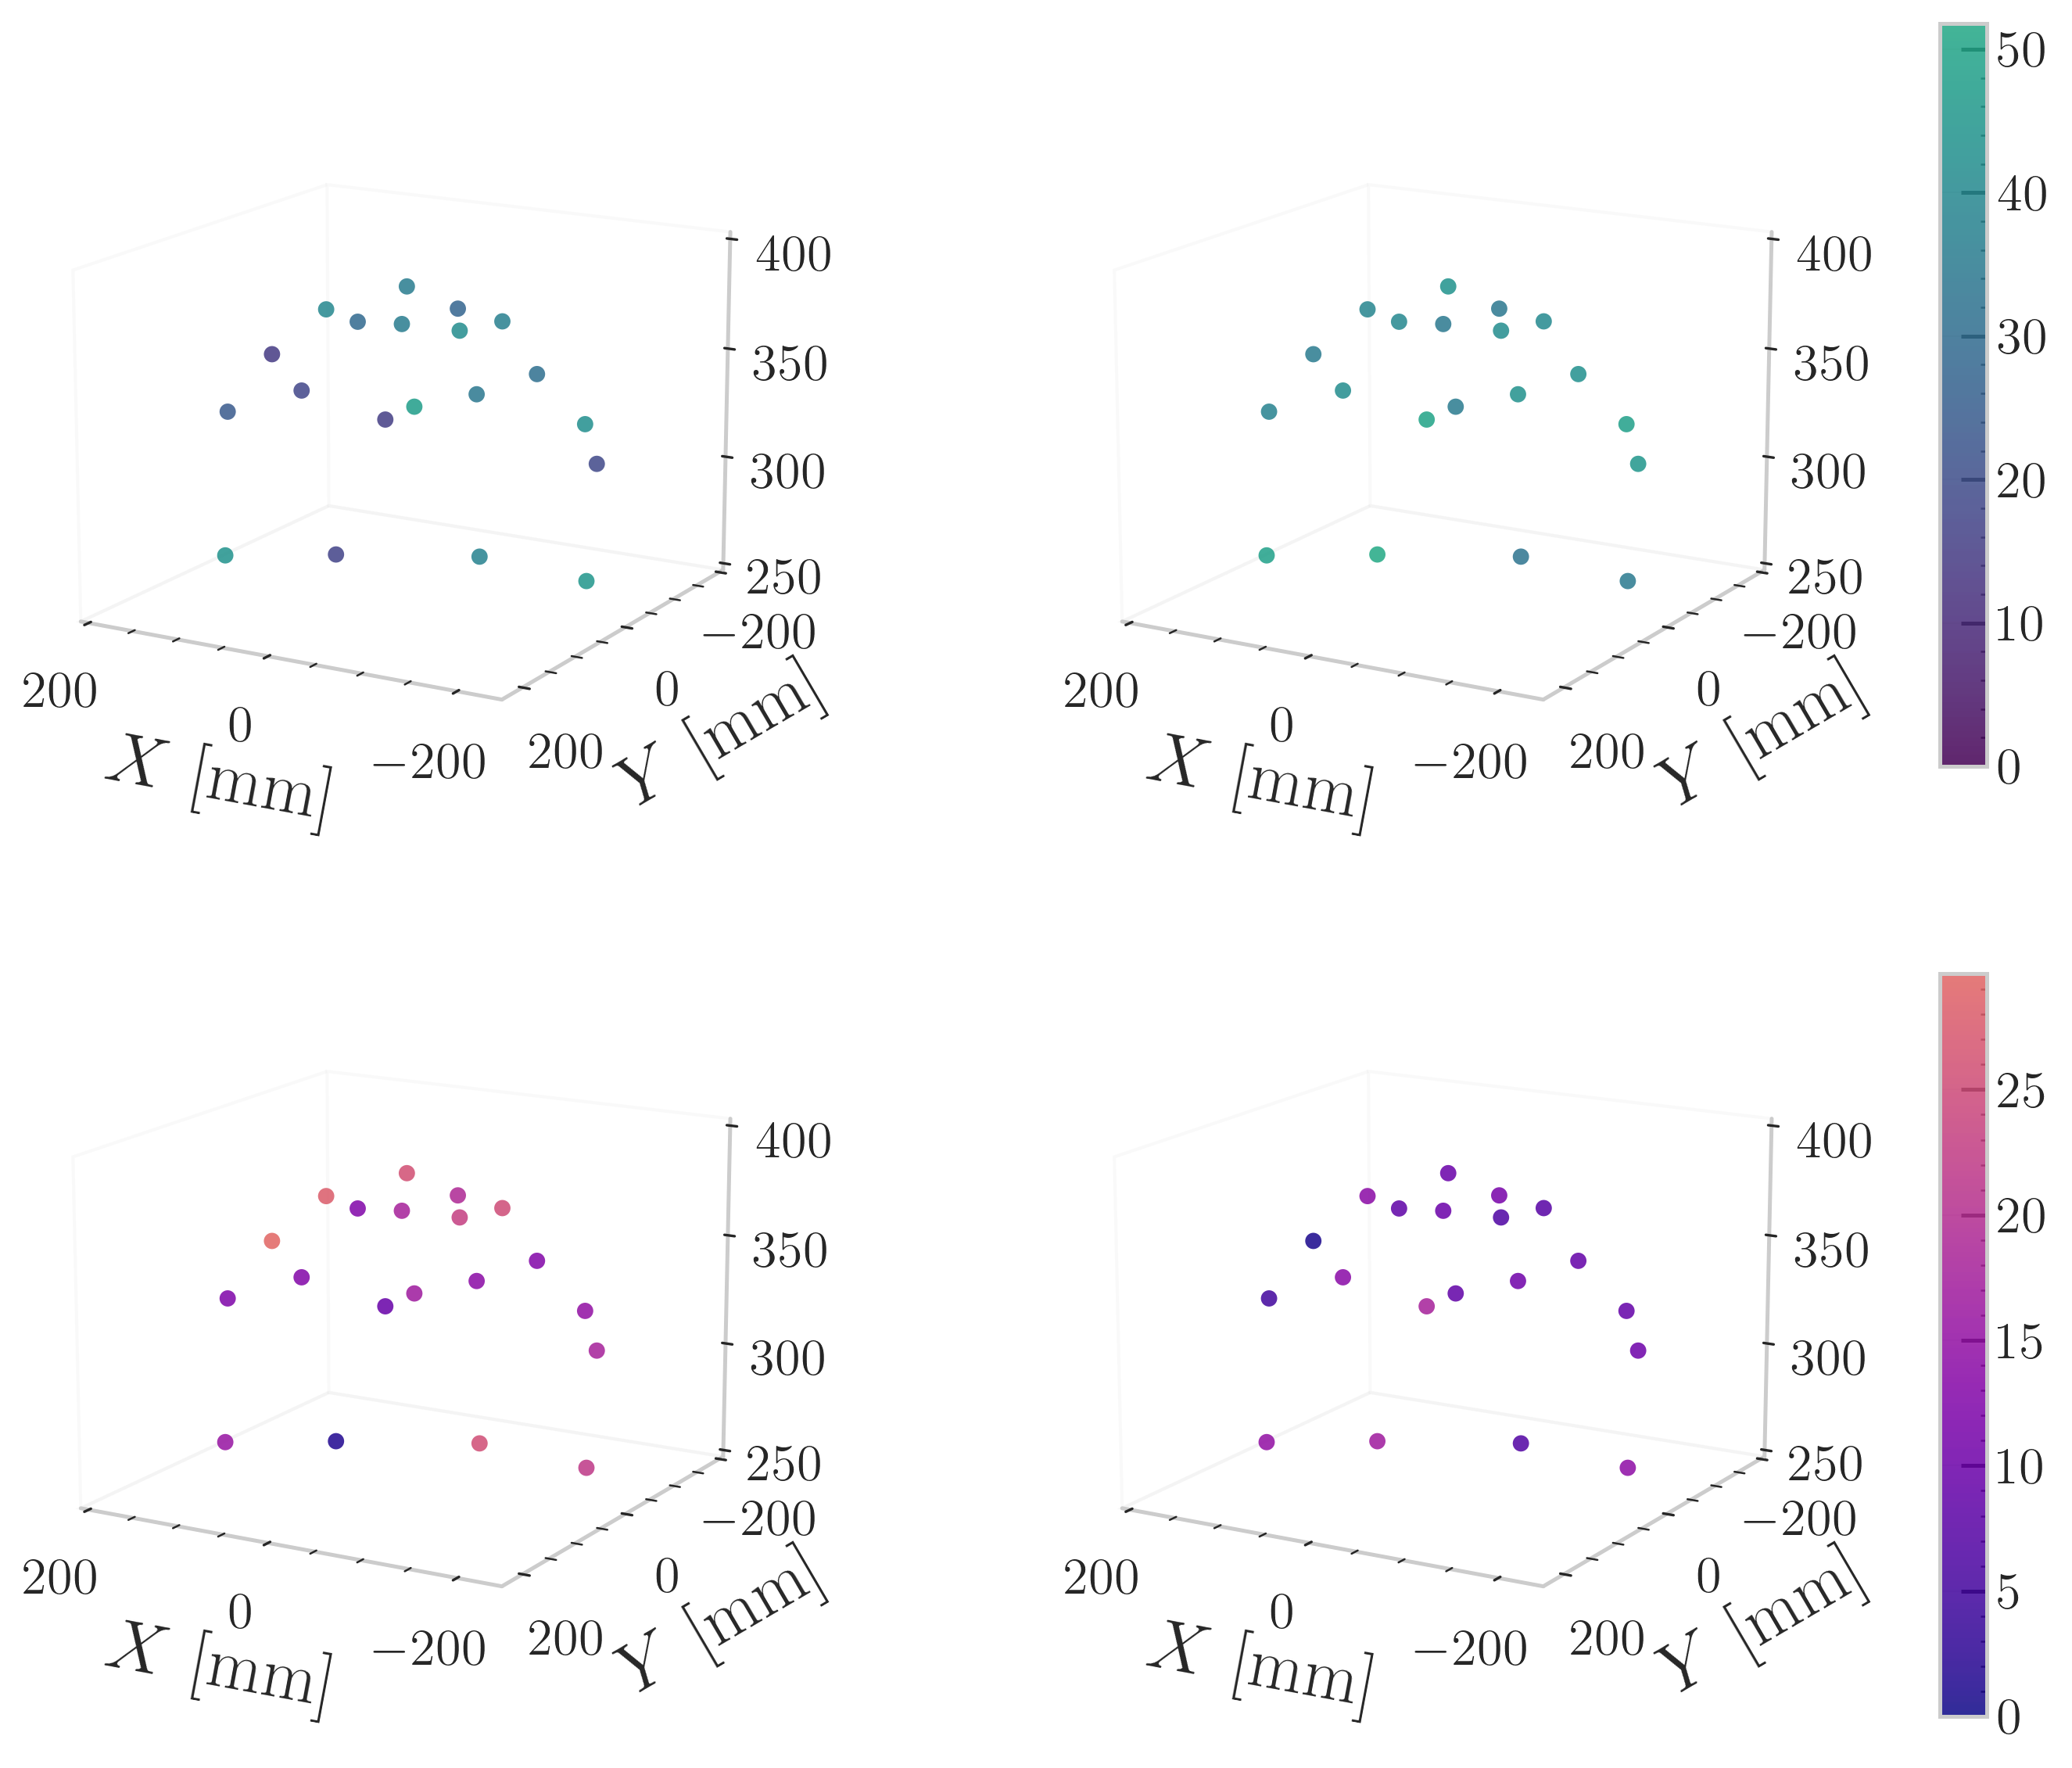


--- Position Error Summary - 20 data points ---
Jacobian - Mean: 31.81 mm, Std: 10.43 mm
Data-driven - Mean: 41.11 mm, Std: 5.57 mm

--- Angular Error Summary ---
Jacobian - Mean: 17.87°, Std: 6.87°
Data-driven - Mean: 10.25°, Std: 4.01°


In [14]:
ComparativeWorkspacePlotting("ControlWorkspaceOpenLoopJacobian.npz", "ControlWorkspaceOpenLoopDatadriven.npz")

## Workspace - datadriven control

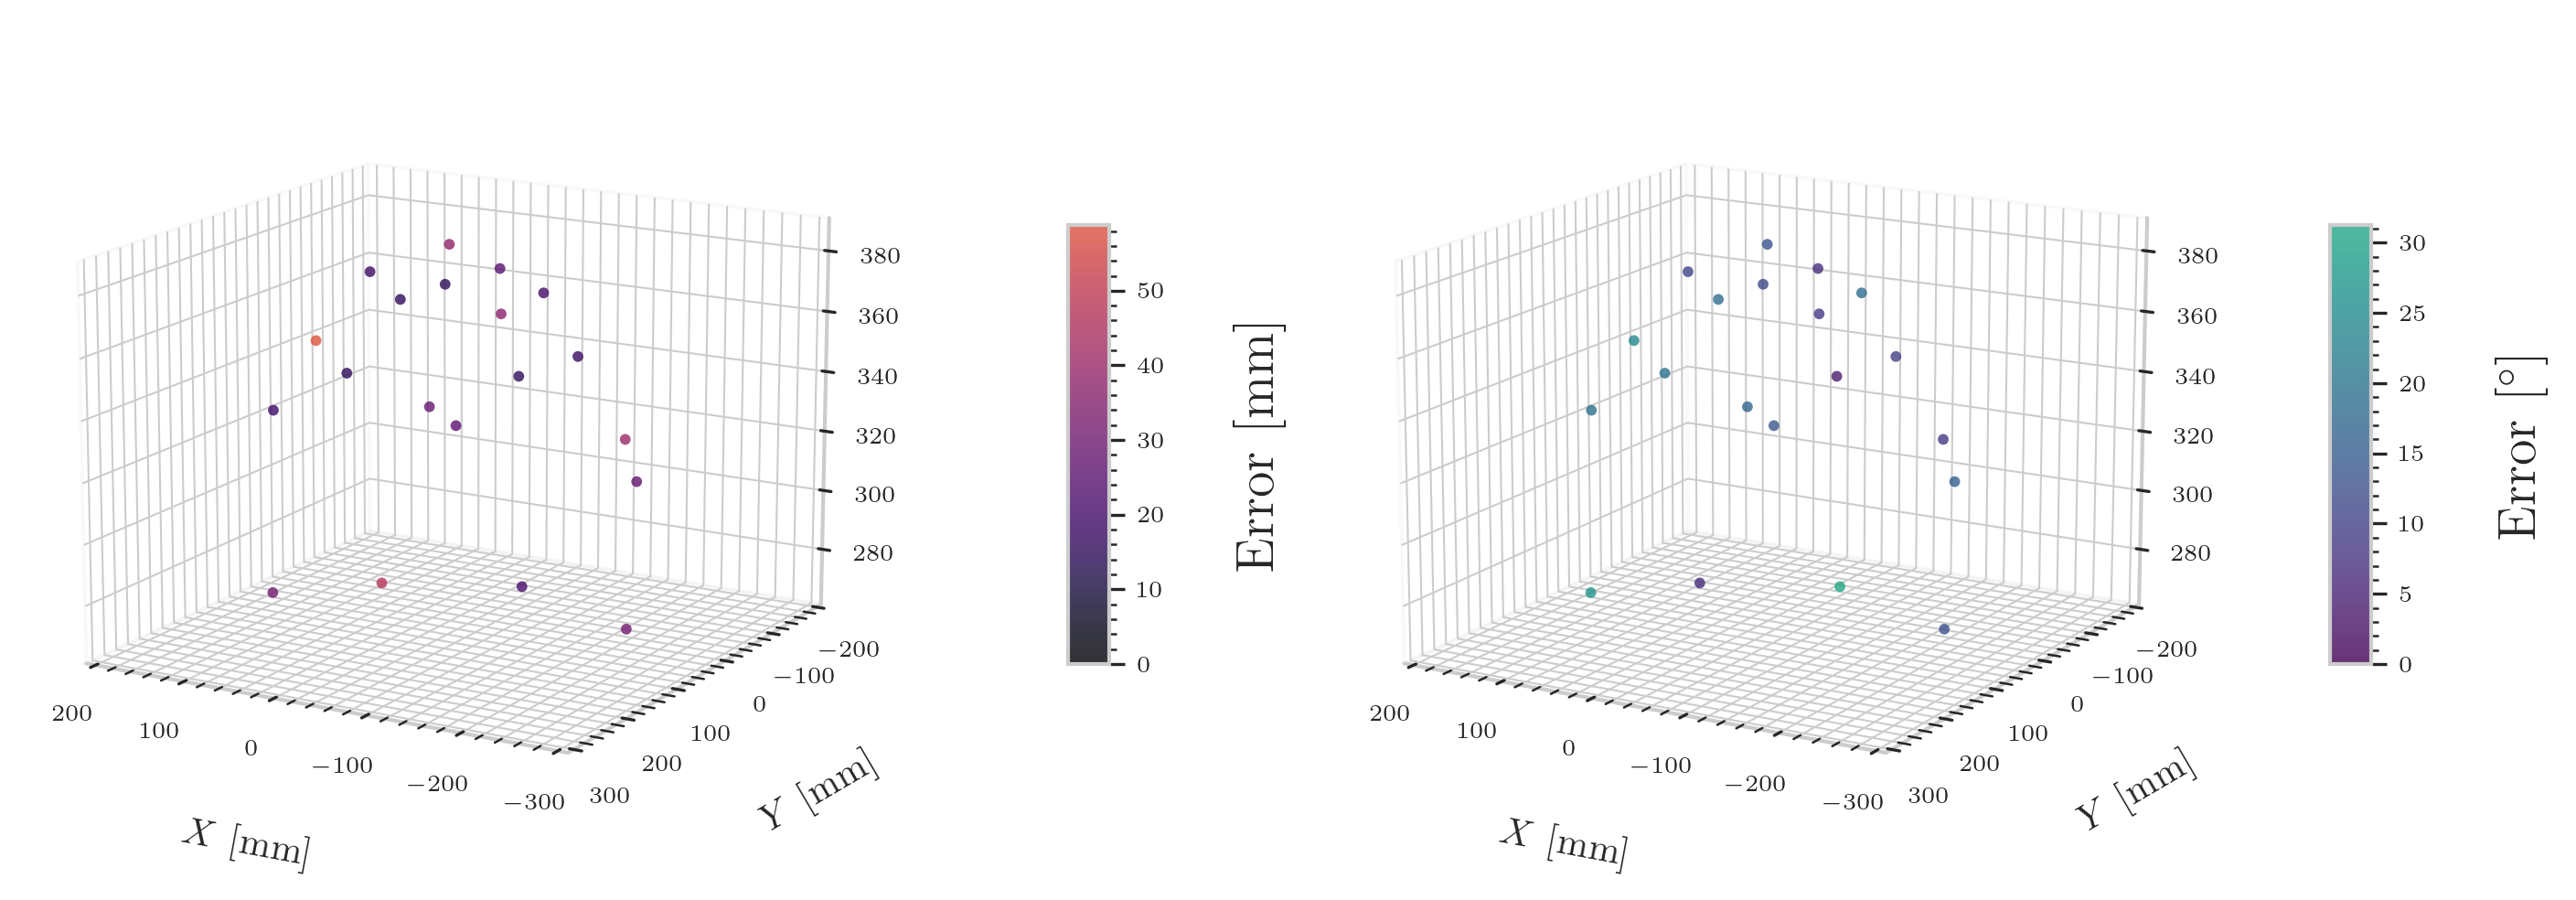


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 27.42 mm
Standard Deviation: 11.60 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 14.72 °
Standard Deviation: 7.00 °


In [11]:
# Performance on the workspace for datadriven control
ClosedLoopWorkspacePlotting("ControlWorkspaceDatadriven.npz", True)

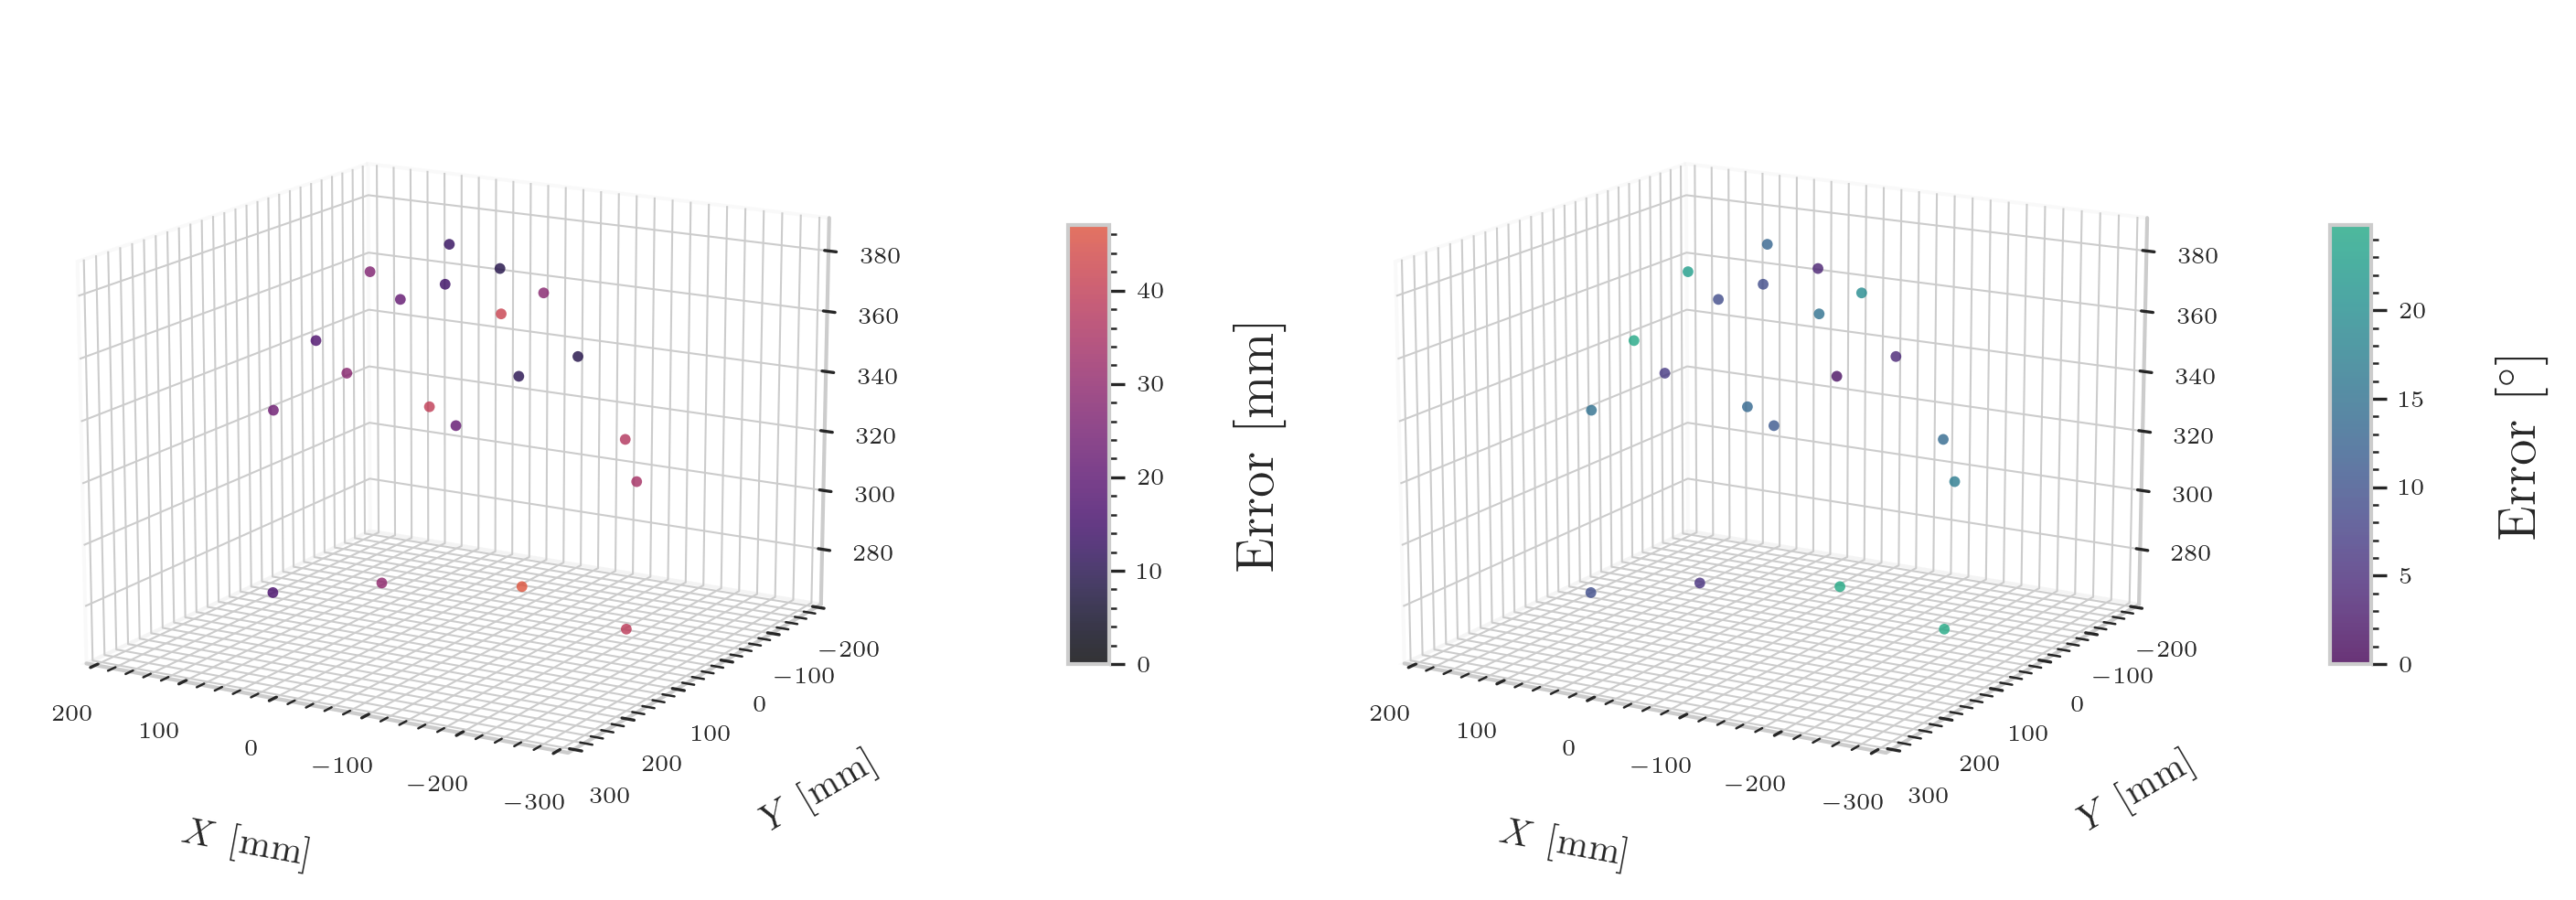


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 25.32 mm
Standard Deviation: 11.42 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 13.21 °
Standard Deviation: 7.10 °


In [12]:
# Performance on the workspace for model-based control
ClosedLoopWorkspacePlotting("ControlWorkspaceJacobian.npz", False)

## Workspace - open loop

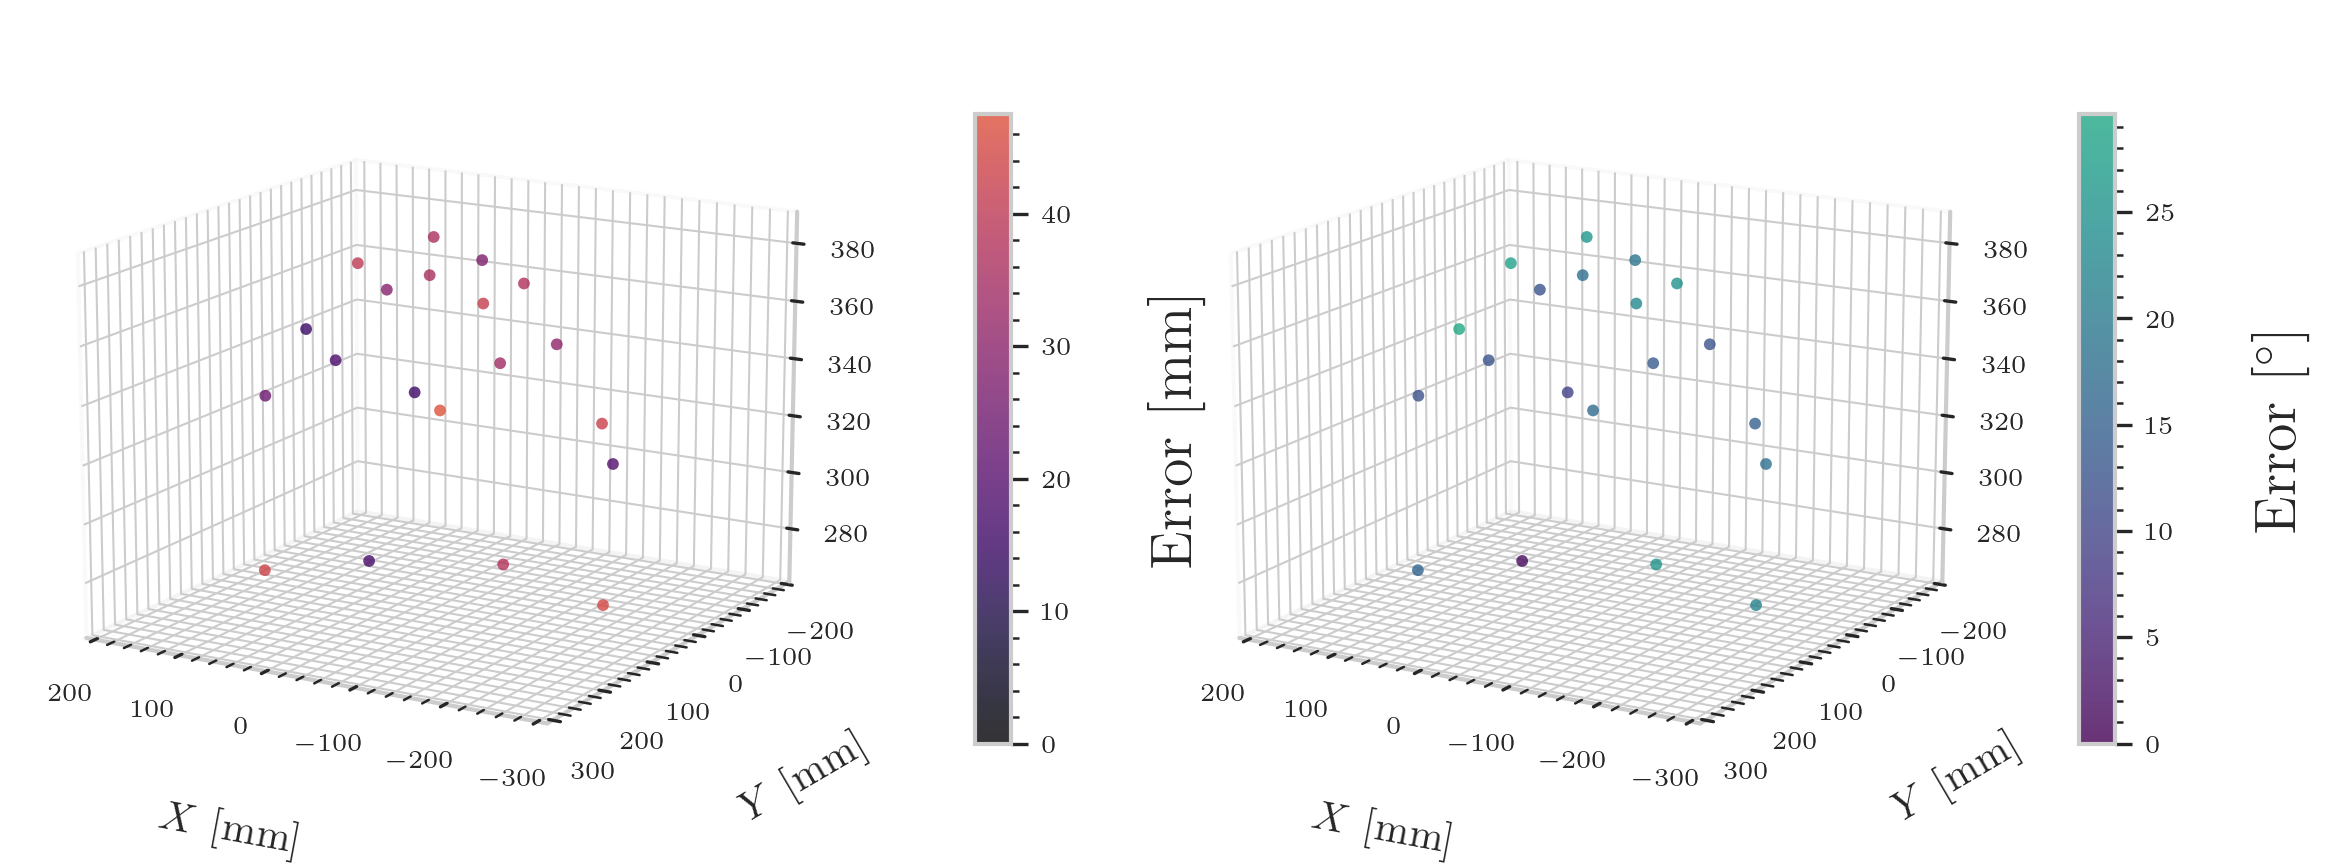


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 31.81 mm
Standard Deviation: 10.43 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 17.87 °
Standard Deviation: 6.87 °


<Figure size 1800x1200 with 0 Axes>


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 31.81 mm
Standard Deviation: 10.43 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 17.87 °
Standard Deviation: 6.87 °


In [13]:
# Performance on the workspace for open loop jacobian control
OpenLoopWorkspacePlotting("ControlWorkspaceOpenLoopJacobian.npz", False)

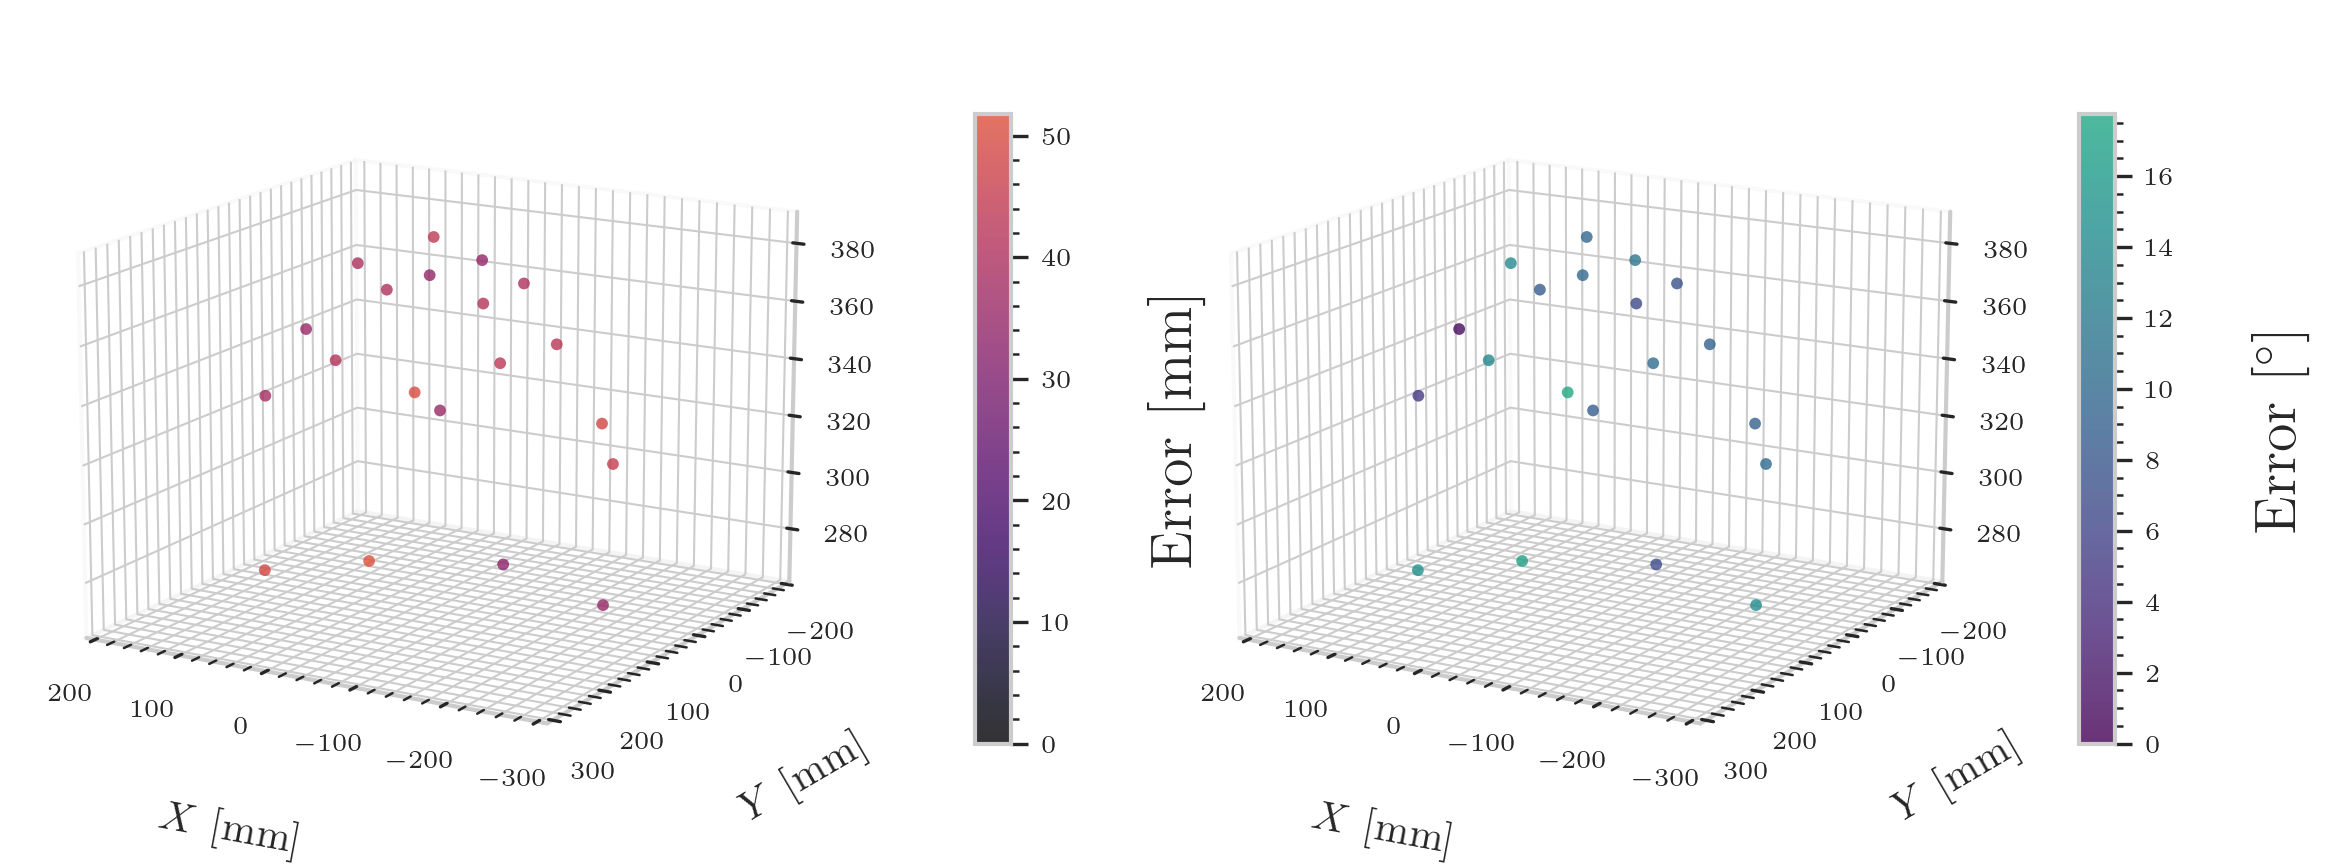


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 41.11 mm
Standard Deviation: 5.57 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 10.25 °
Standard Deviation: 4.01 °


<Figure size 1800x1200 with 0 Axes>


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 41.11 mm
Standard Deviation: 5.57 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 10.25 °
Standard Deviation: 4.01 °


In [14]:
# Datadriven control on the workspace
OpenLoopWorkspacePlotting("ControlWorkspaceOpenLoopDatadriven.npz", True)

## Circle plots

Closed-loop

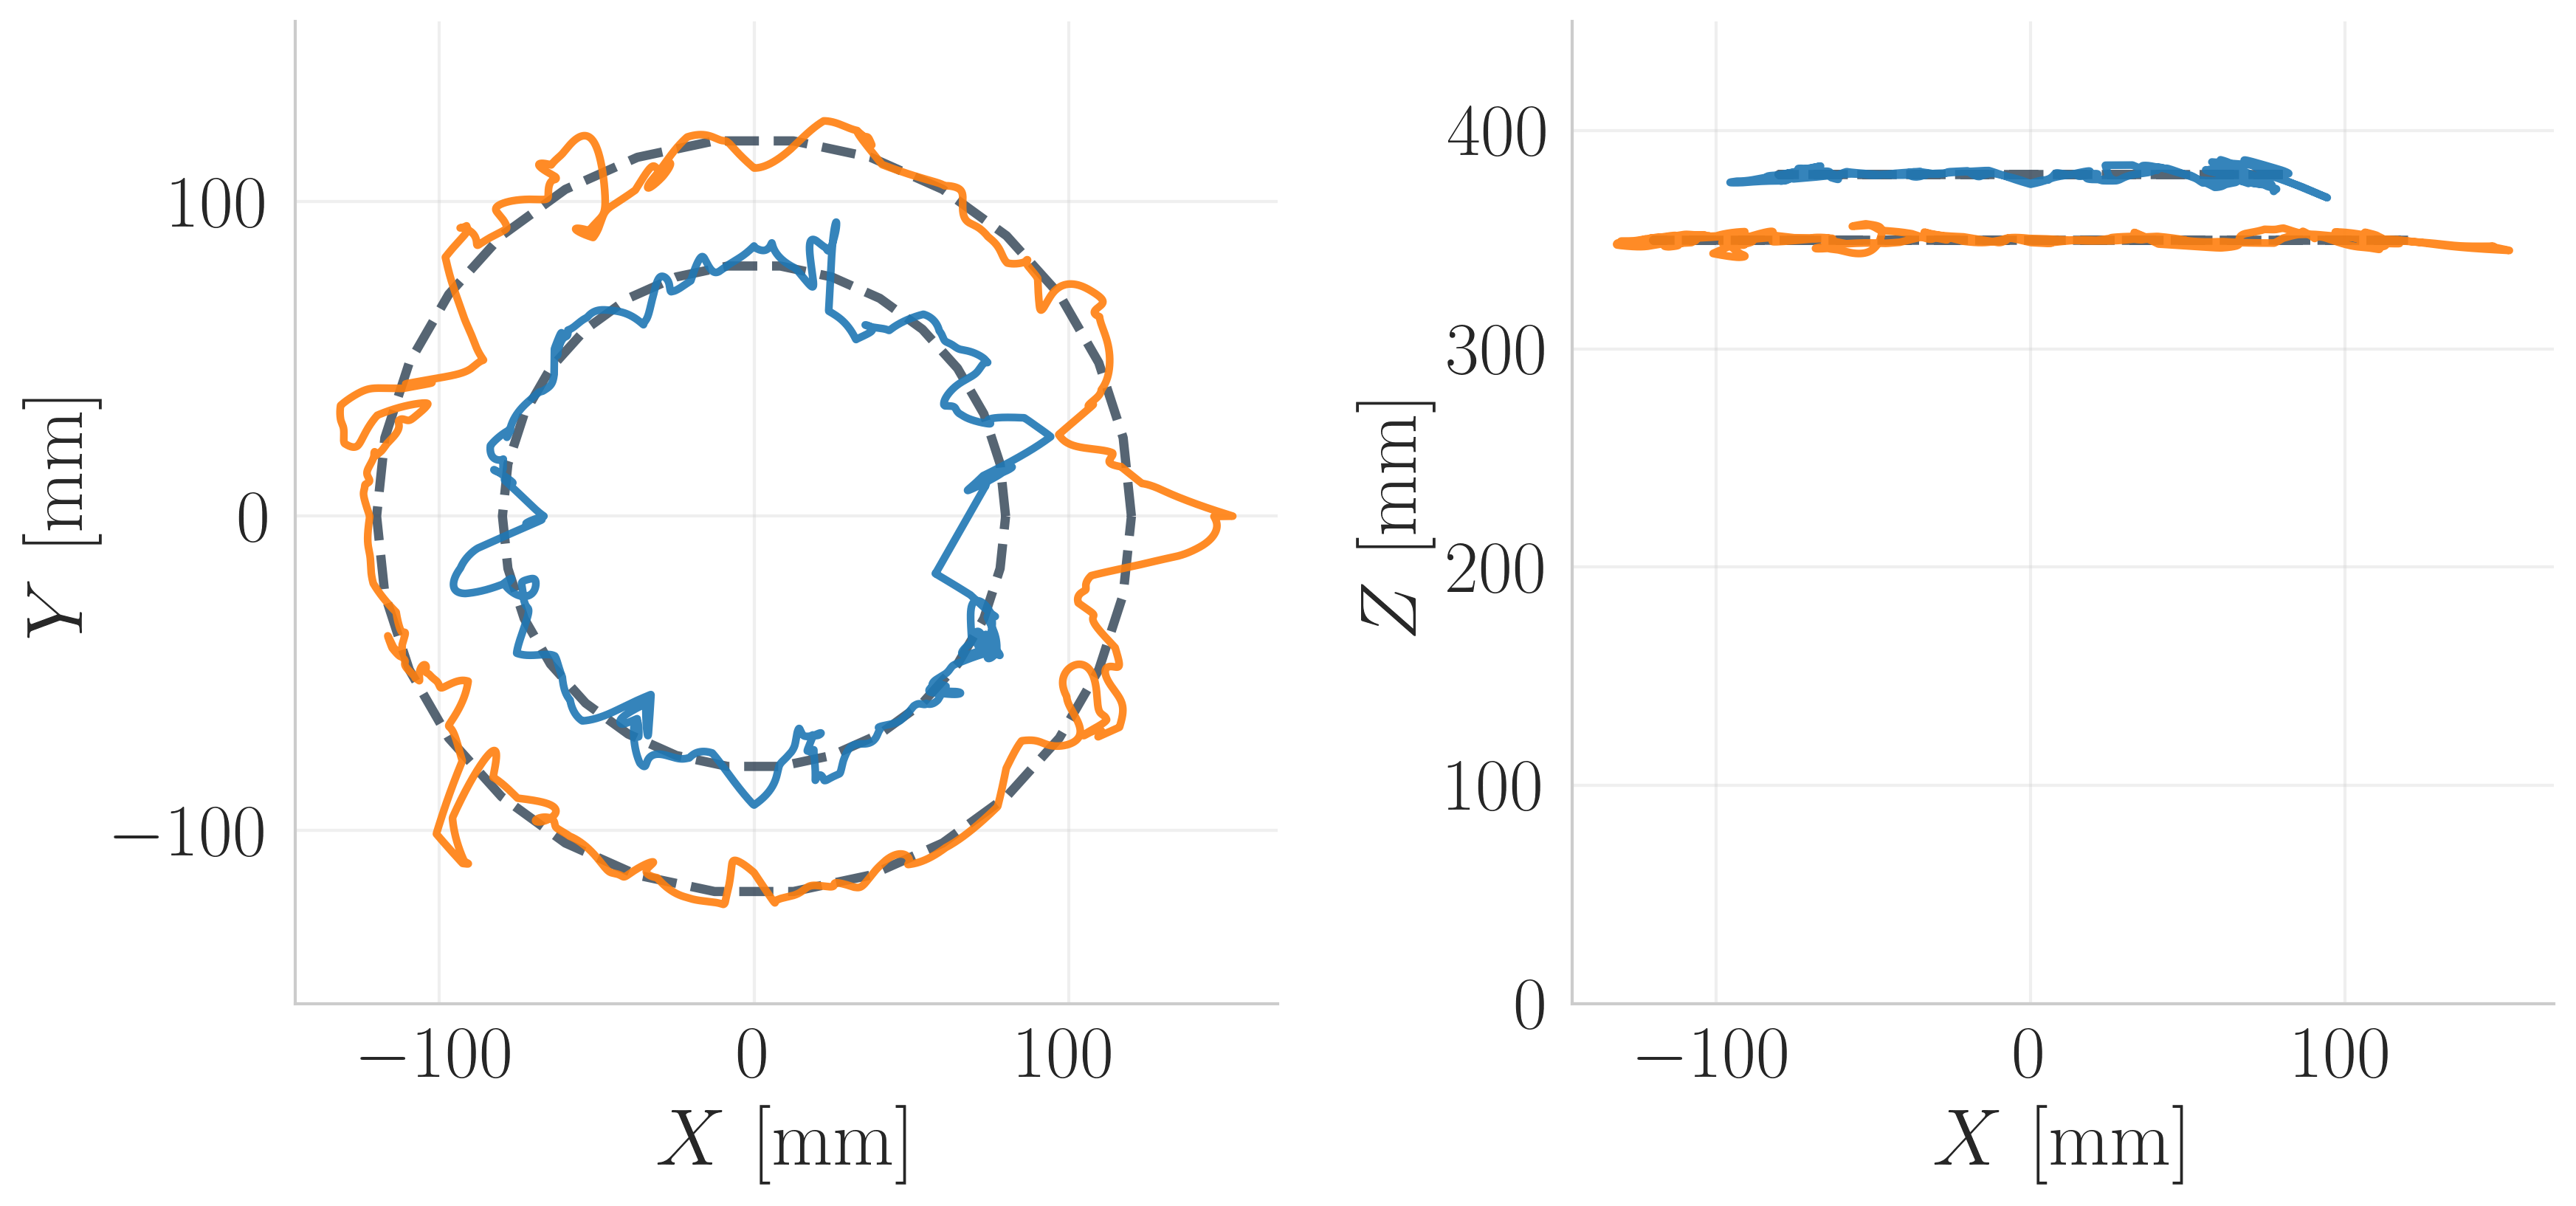

Plotted 2 configurations for Circle - datadriven control

--- Angular Error Analysis for Circle - datadriven control ---
r=80mm, h=380mm: 8.81 ± 0.01 $^\circ$
r=120mm, h=350mm: 16.07 ± 0.01 $^\circ$


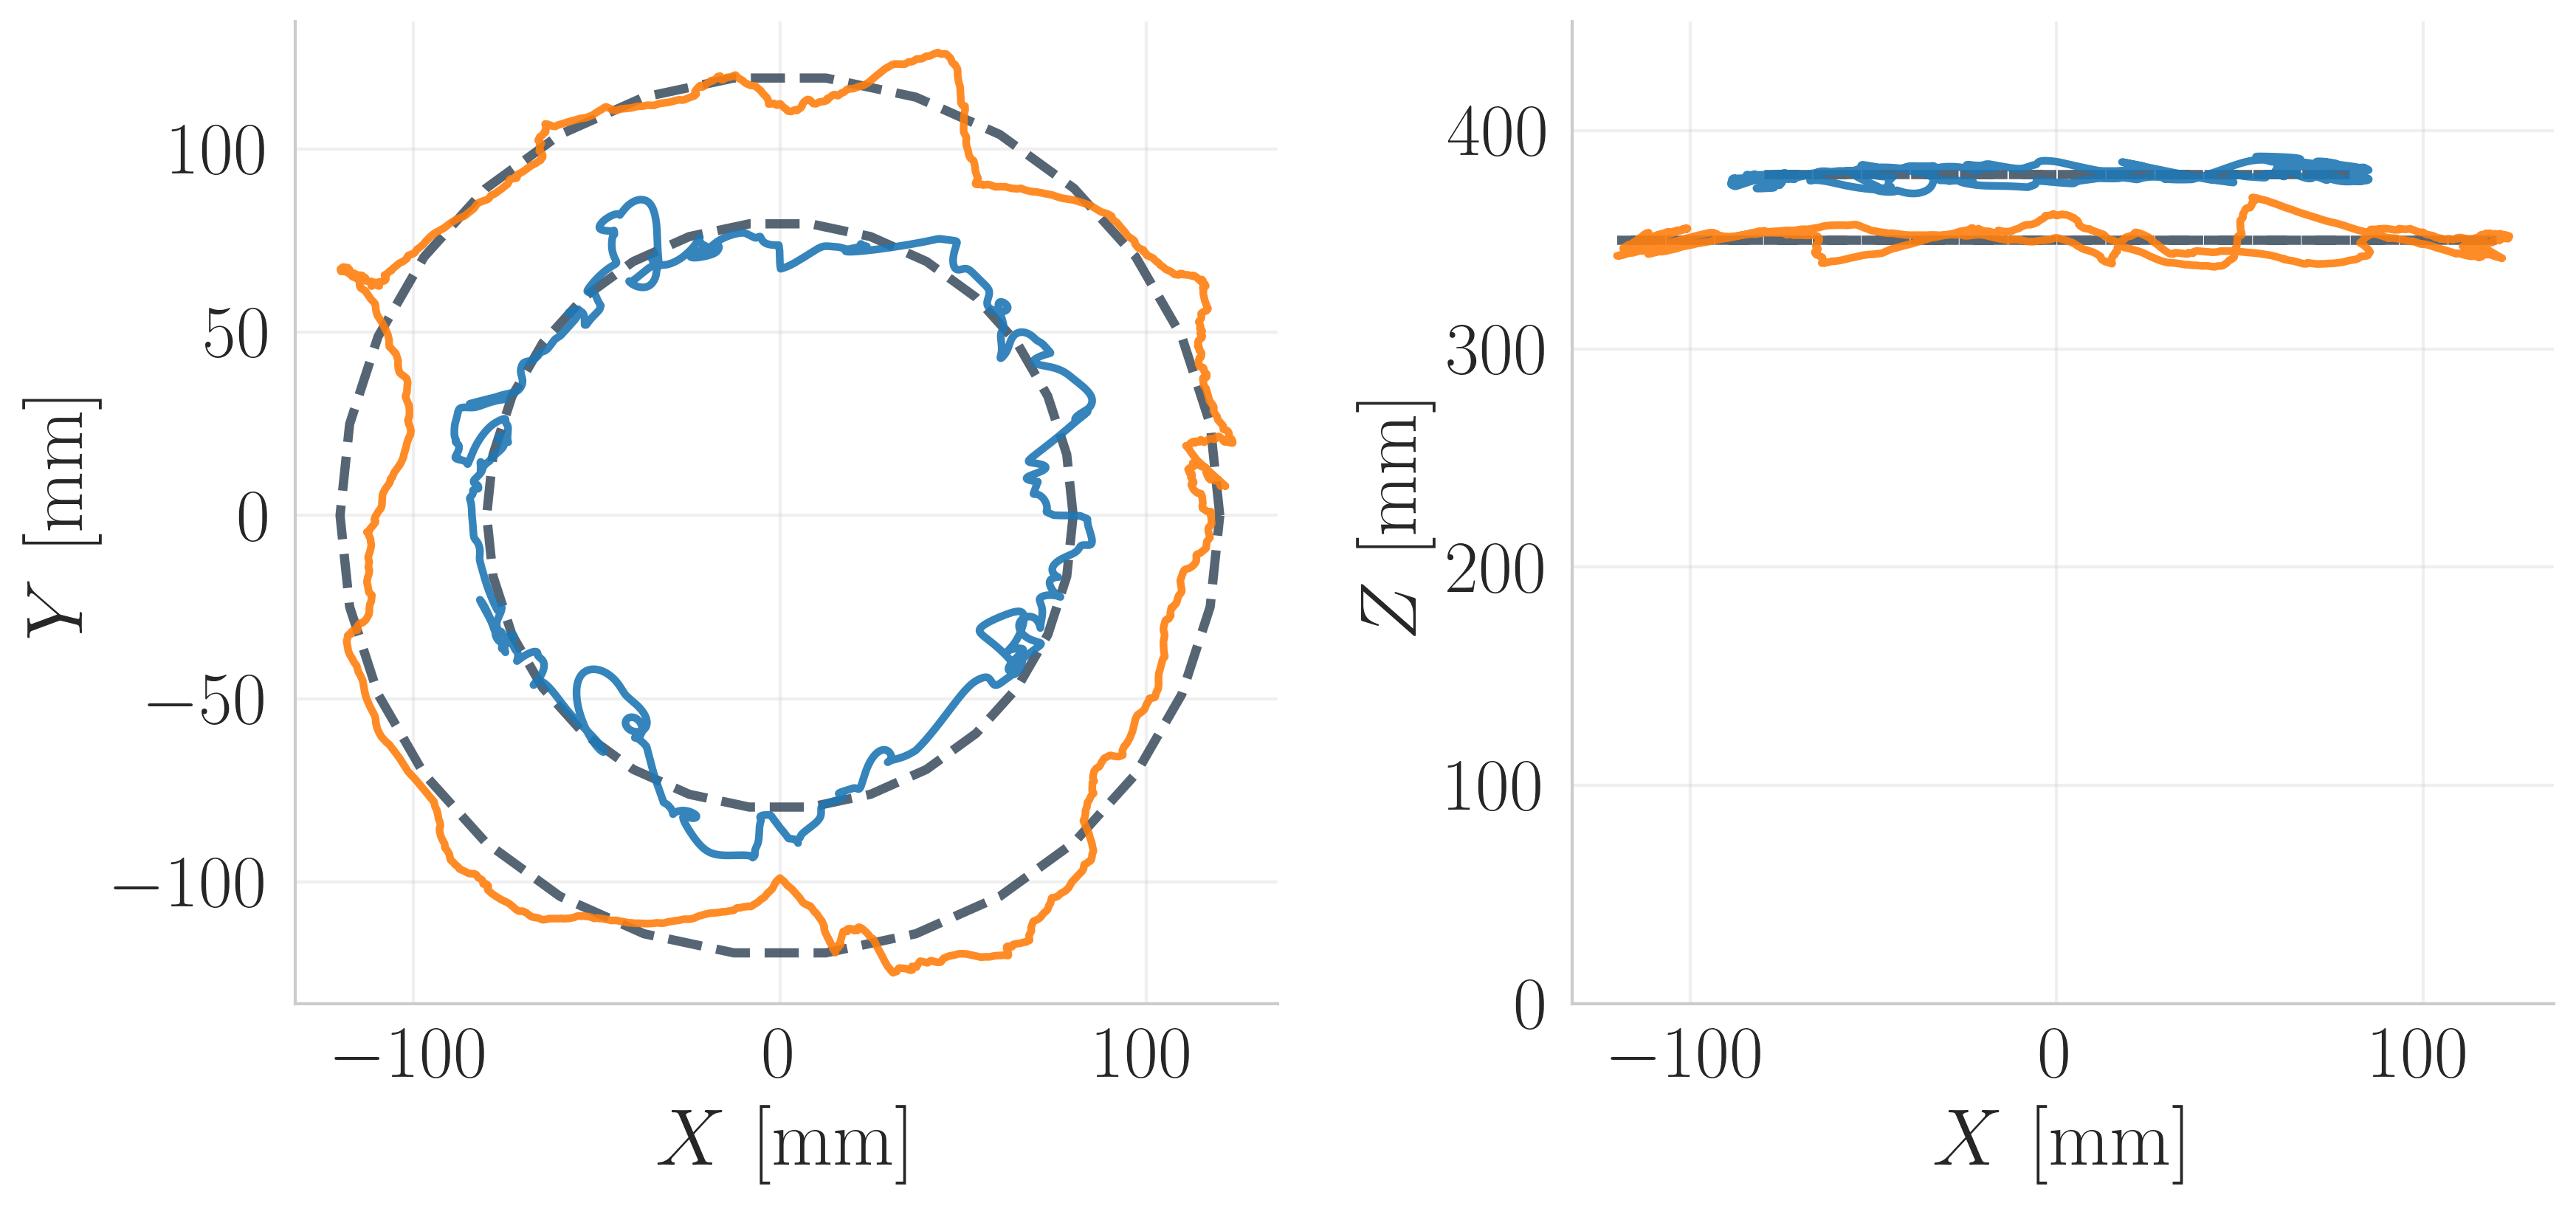

Plotted 2 configurations for Circle - jacobian control

--- Angular Error Analysis for Circle - jacobian control ---
r=80mm, h=380mm: 25.06 ± 3.97 $^\circ$
r=120mm, h=350mm: 18.39 ± 3.12 $^\circ$


In [15]:
# Circle, closed loop
ClosedLoopPolygonPlotting("datadriven", 30)
ClosedLoopPolygonPlotting("jacobian", 30)

Open-loop behaviors

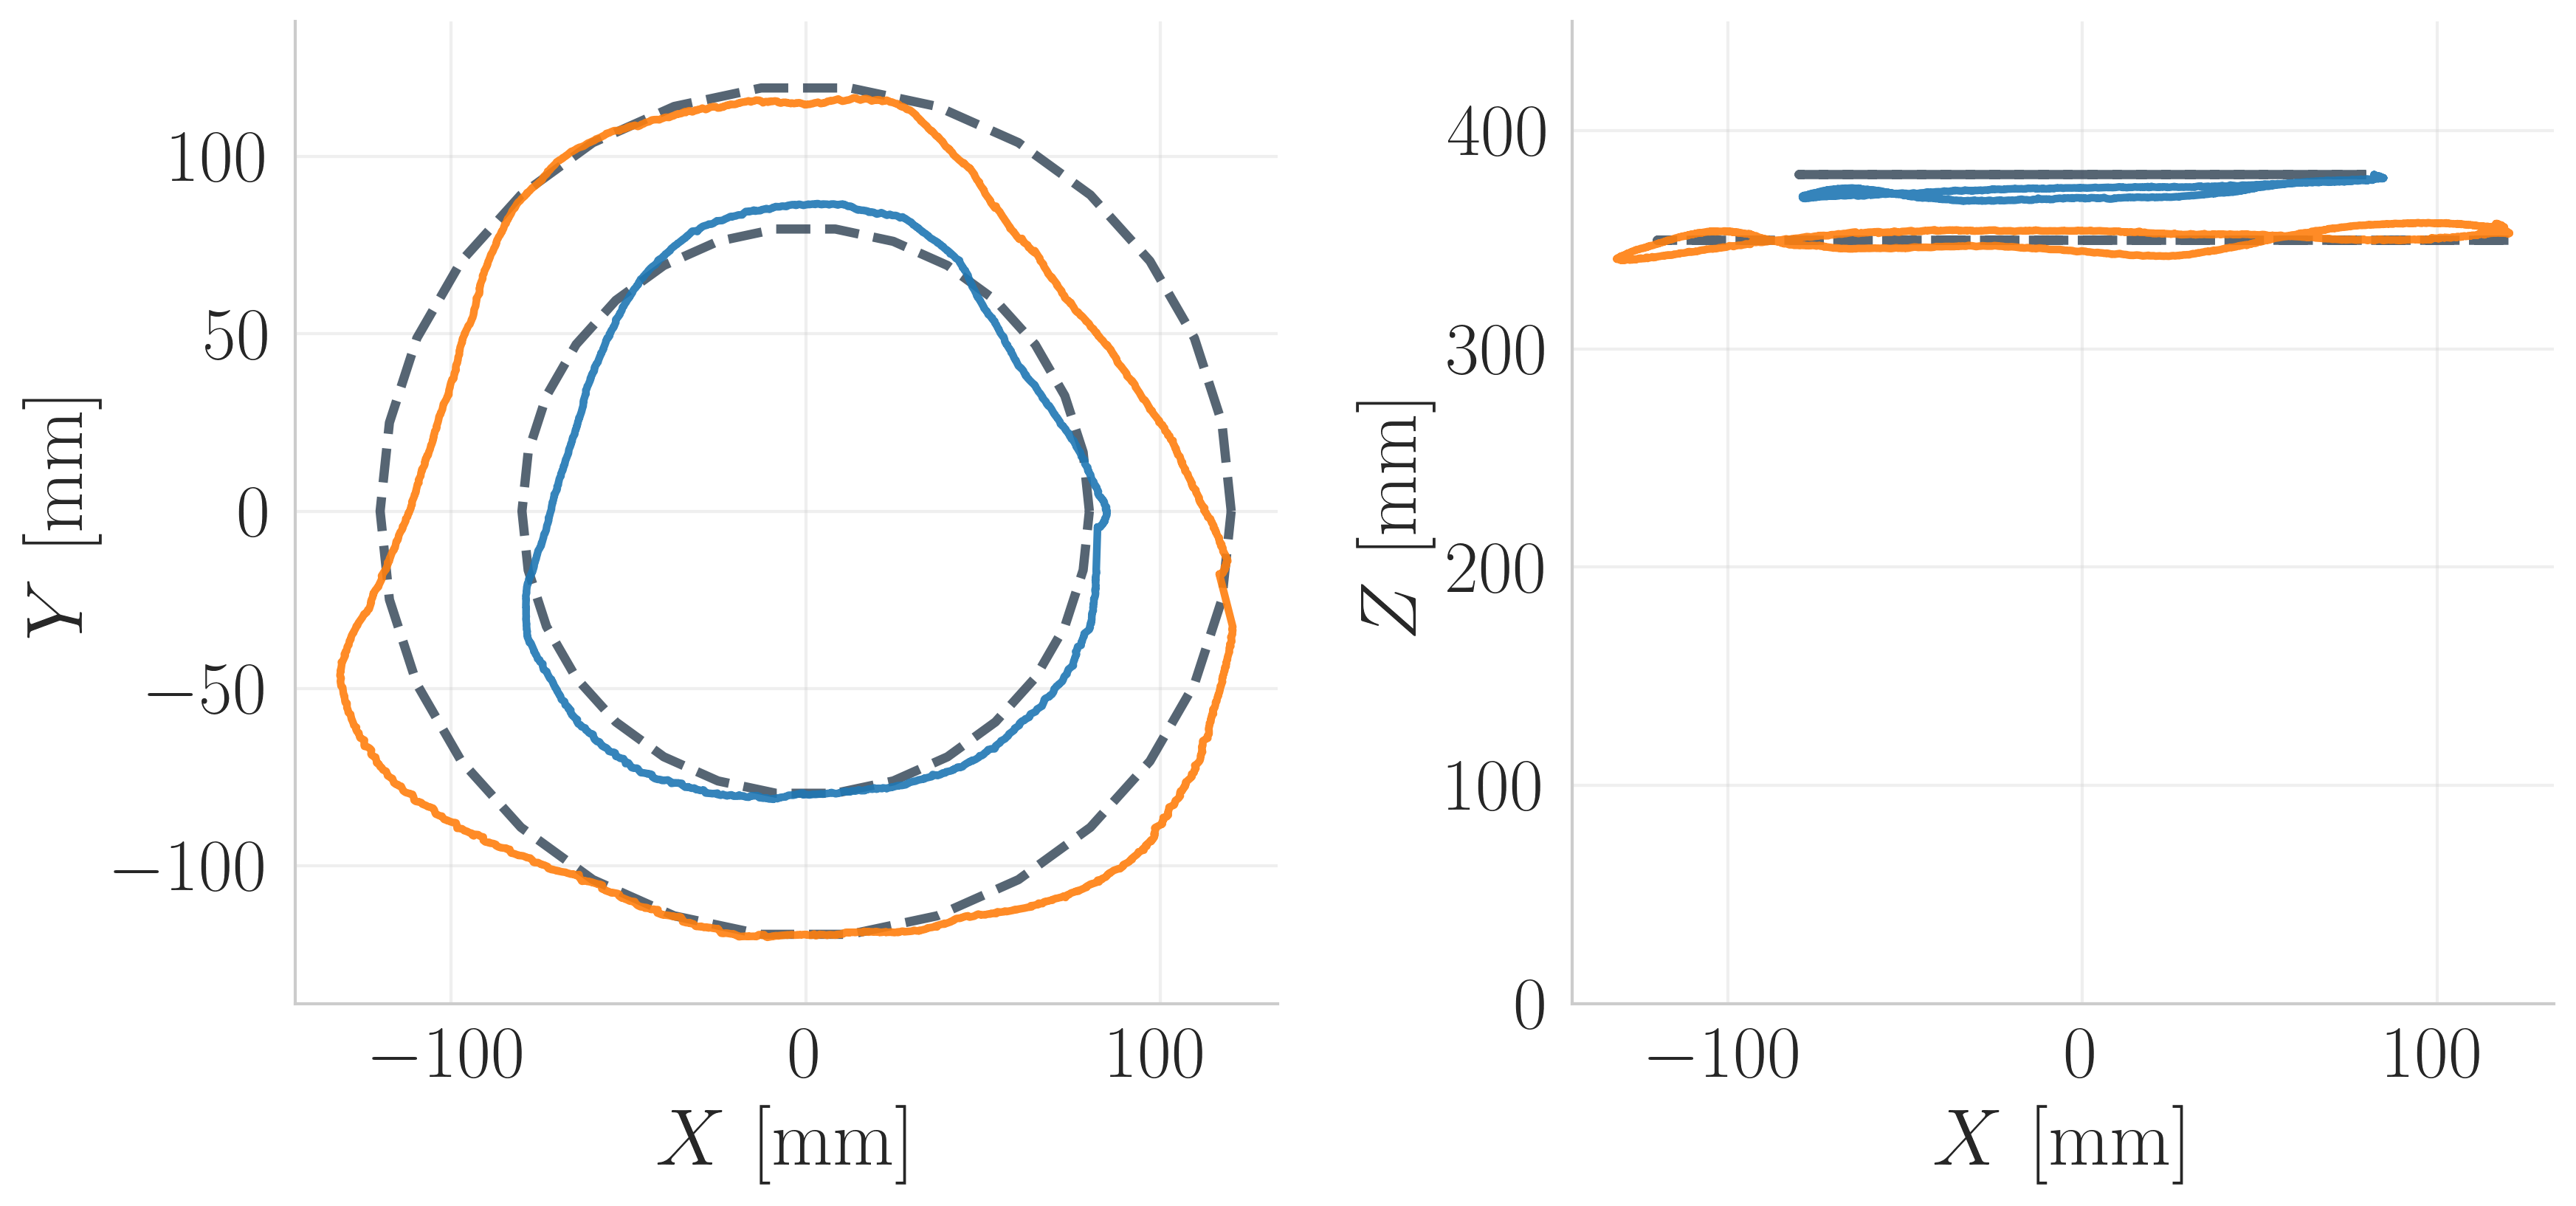

Plotted 2 configurations for Circle - datadriven control

--- Angular Error Analysis for Circle - datadriven control - Open Loop ---
r=80mm, h=380mm: 28.29 ± 3.20 $^\circ$
r=120mm, h=350mm: 42.12 ± 4.54 $^\circ$


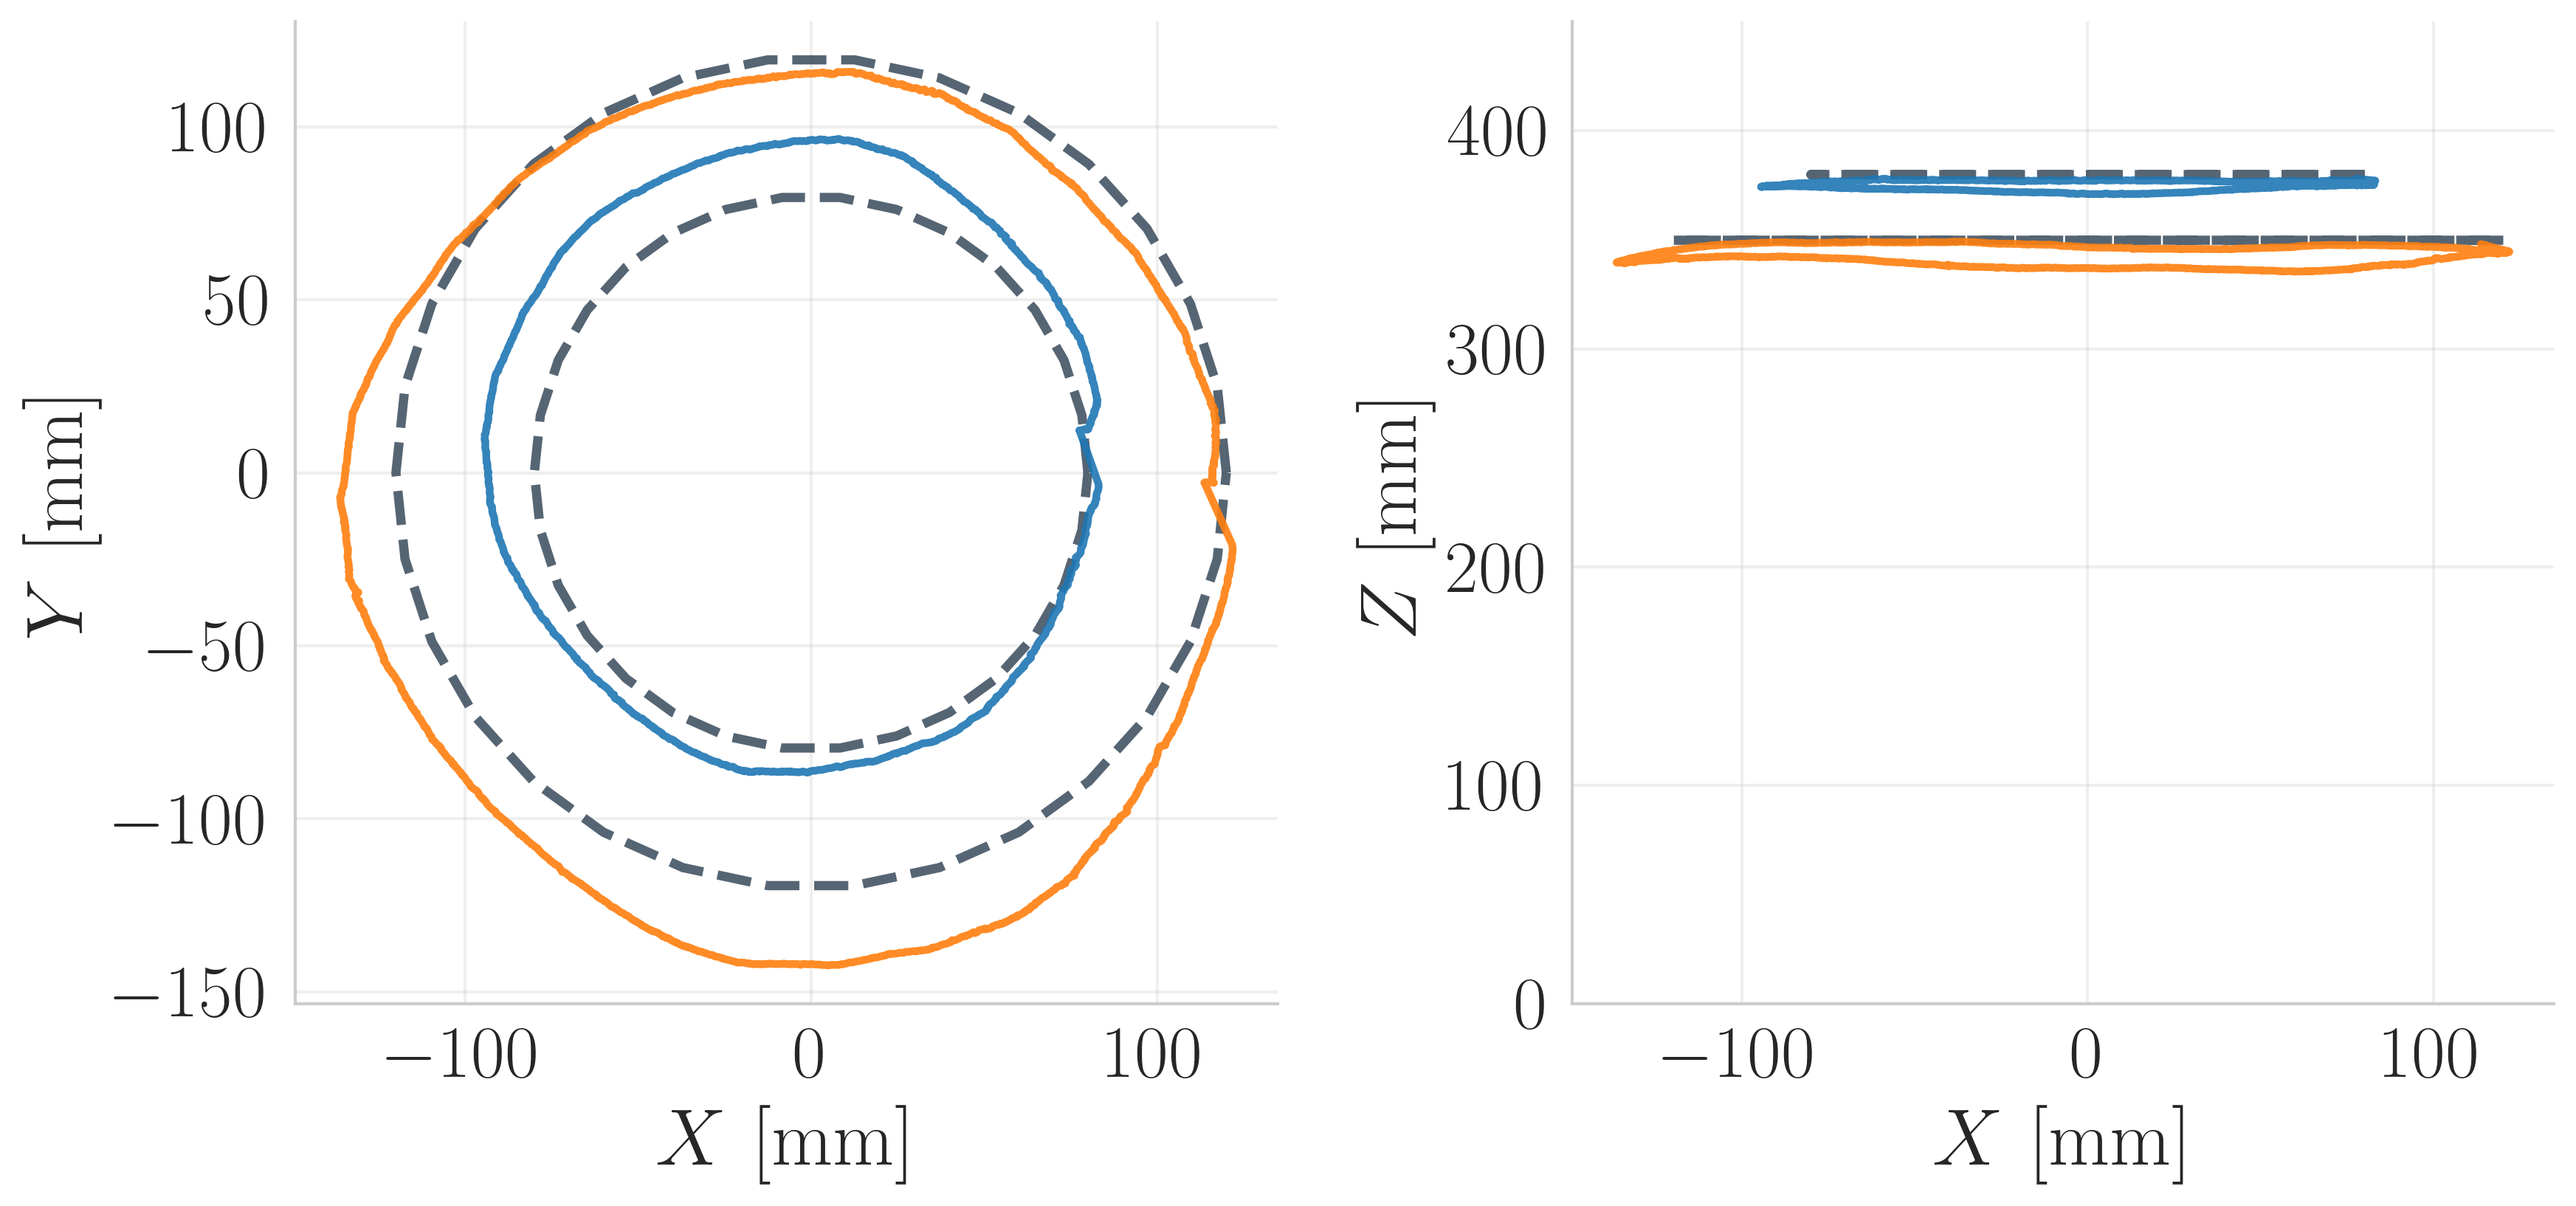

Plotted 2 configurations for Circle - jacobian control

--- Angular Error Analysis for Circle - jacobian control - Open Loop ---
r=80mm, h=380mm: 32.34 ± 3.62 $^\circ$
r=120mm, h=350mm: 42.71 ± 5.87 $^\circ$


In [16]:
# Circle, open loop, both
OpenLoopPolygonPlotting("datadriven", 30)
OpenLoopPolygonPlotting("jacobian", 30)

## 😓 Weighted plots

Workspace analysis


PLOTTING RESULTS FOR WEIGHT: W50g

--- Workspace Jacobian (W50g) ---


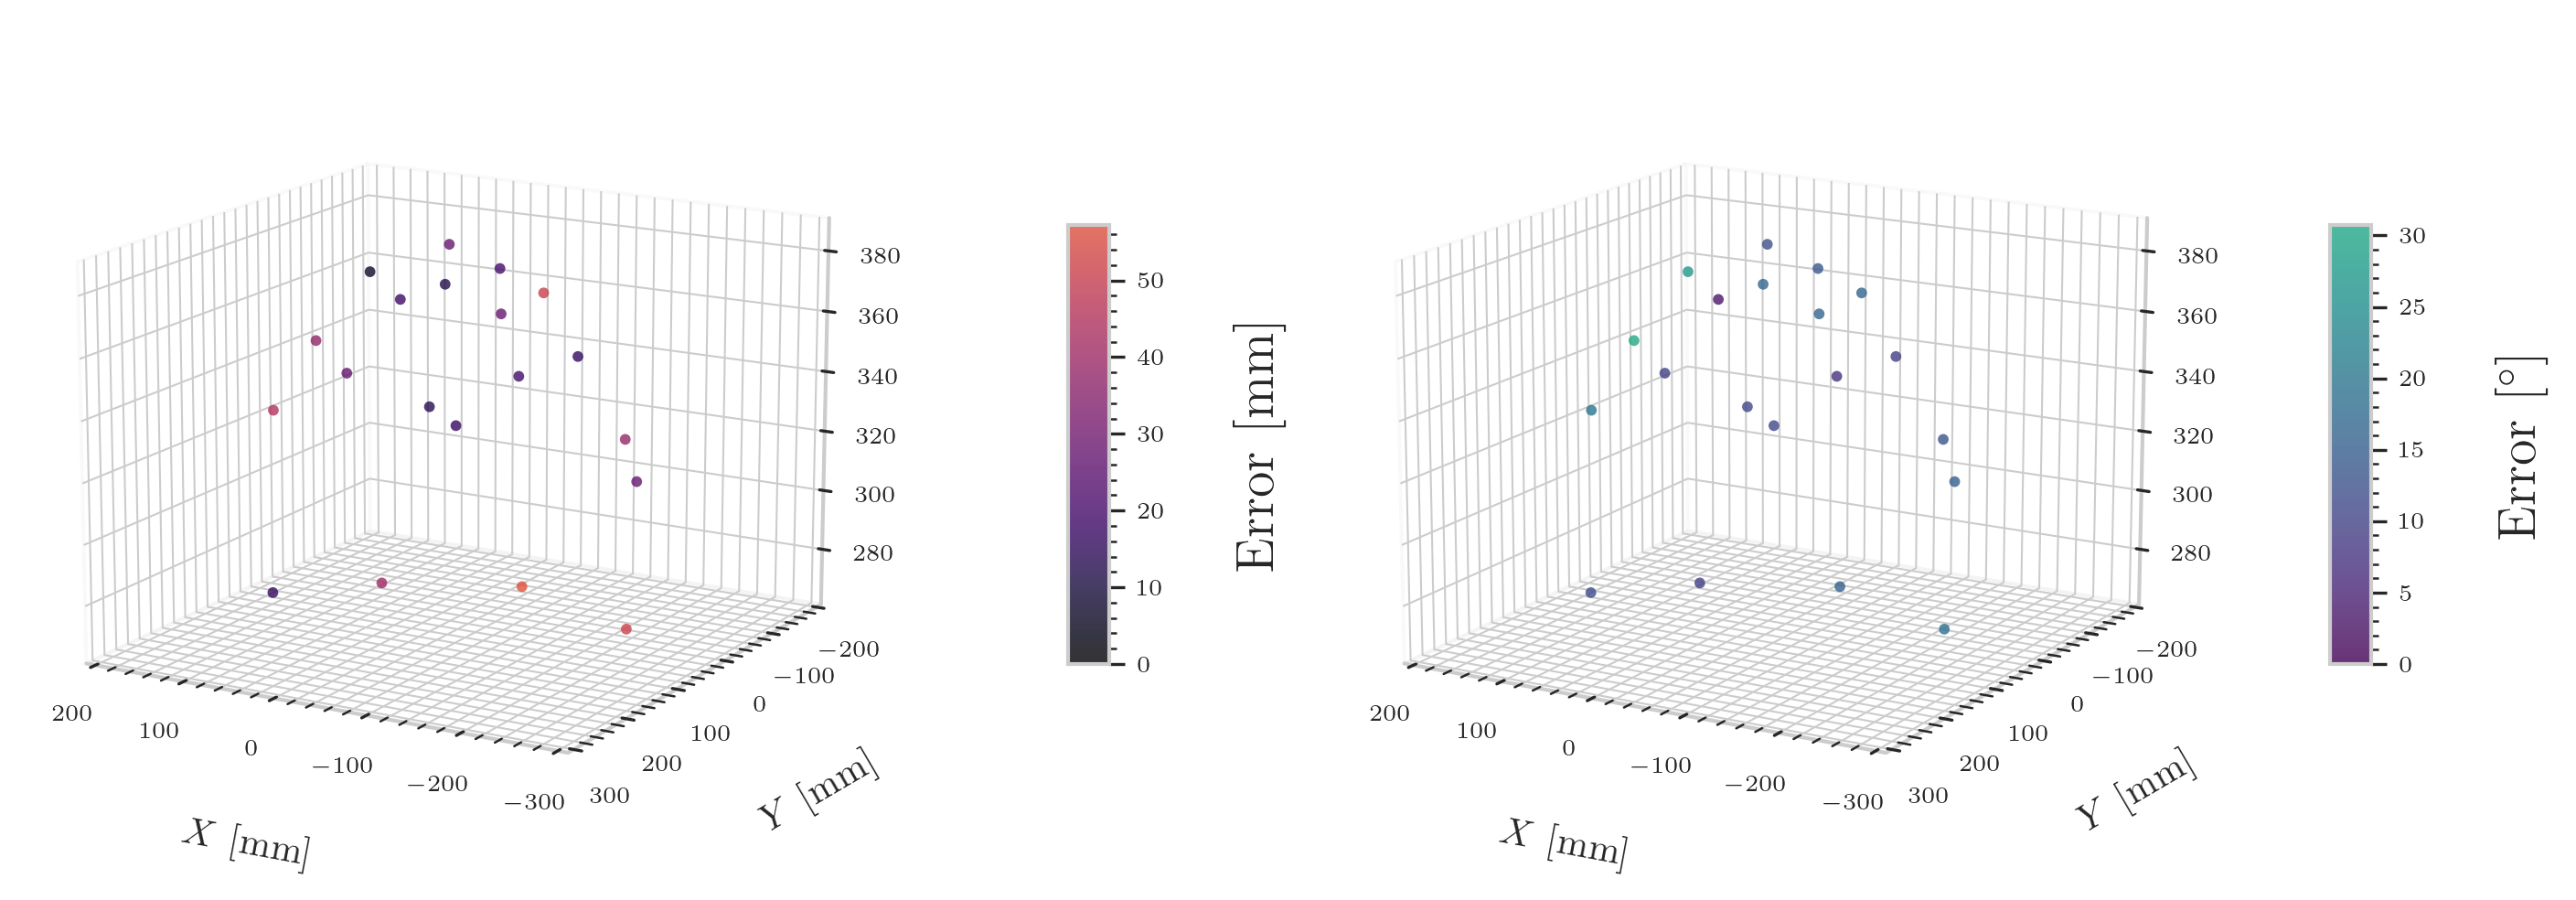


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 28.55 mm
Standard Deviation: 14.40 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 14.39 °
Standard Deviation: 6.28 °

--- Workspace Closed Loop (W50g) ---


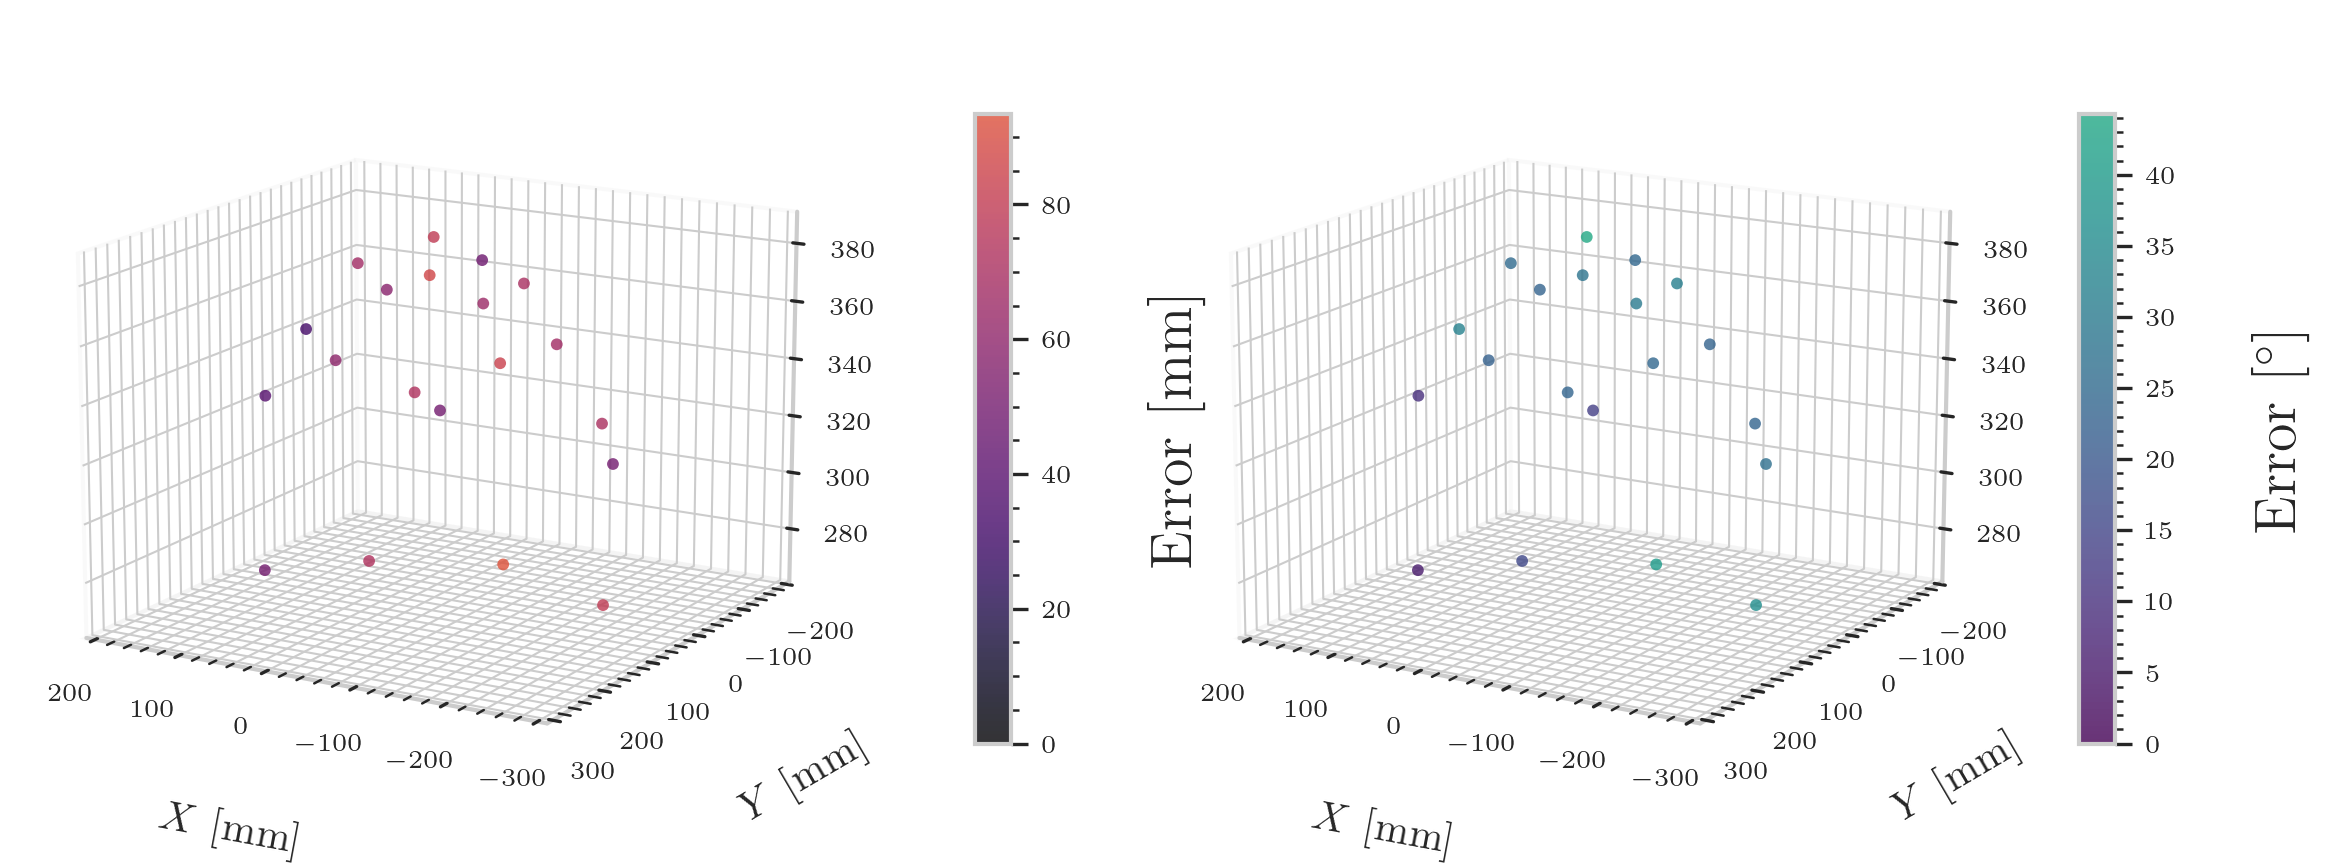


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 64.56 mm
Standard Deviation: 15.96 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 25.16 °
Standard Deviation: 9.25 °


<Figure size 1800x1200 with 0 Axes>


--- Position Error Summary (Target vs Mocap) - 20 data ---
Mean Error: 64.56 mm
Standard Deviation: 15.96 mm

--- Angular Error Summary (Target vs Mocap) ---
Mean Error: 25.16 °
Standard Deviation: 9.25 °


In [17]:
# Measured final perturbation weight
w_string = "W50g"

# Plotting results for the disturbed controller
print(f"\n{'='*60}")
print(f"PLOTTING RESULTS FOR WEIGHT: {w_string}")
print(f"{'='*60}")

# CL jacobian
print(f"\n--- Workspace Jacobian ({w_string}) ---")
ClosedLoopWorkspacePlotting(f"ControlWorkspaceJacobian_{w_string}.npz", False)

# OL jacobian
print(f"\n--- Workspace Closed Loop ({w_string}) ---")
OpenLoopWorkspacePlotting(f"ControlWorkspaceOpenLoopJacobian_{w_string}.npz", False)

Closed-Loop Synthetic Plotting

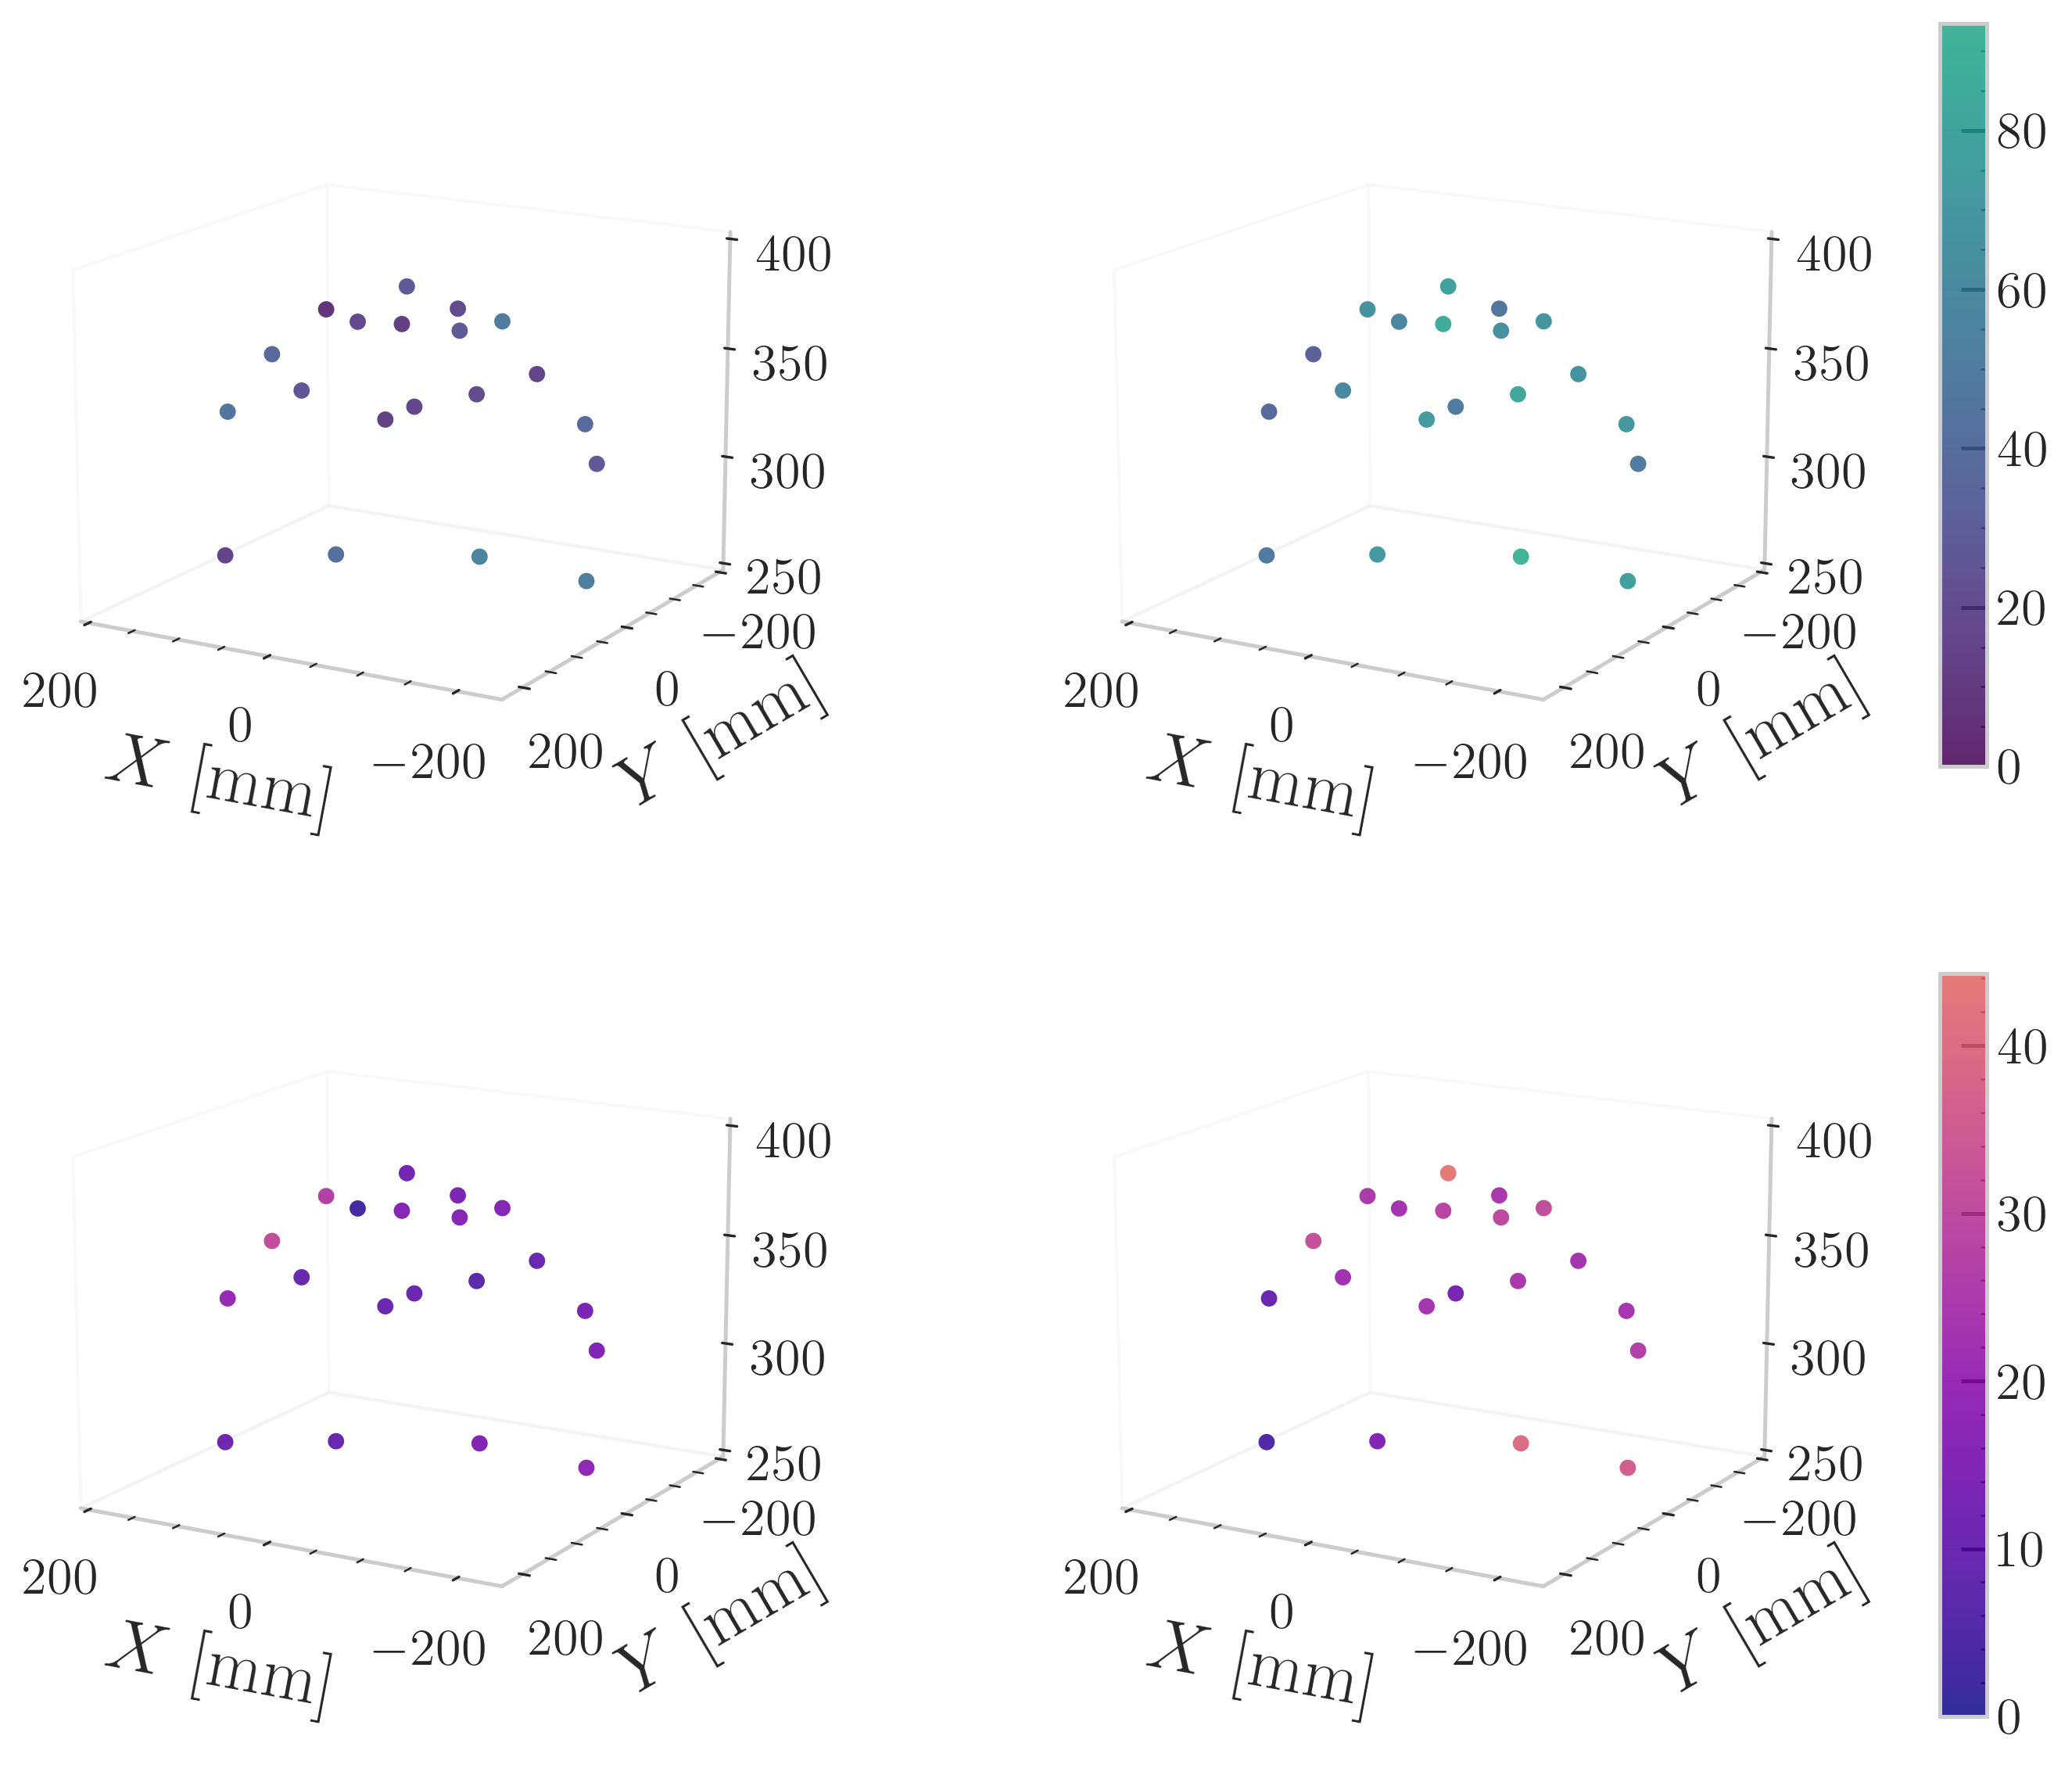


--- Position Error Summary - 20 data points ---
Jacobian - Mean: 28.55 mm, Std: 14.40 mm
Data-driven - Mean: 64.56 mm, Std: 15.96 mm

--- Angular Error Summary ---
Jacobian - Mean: 14.39°, Std: 6.28°
Data-driven - Mean: 25.16°, Std: 9.25°


In [18]:
ComparativeWorkspacePlotting("ControlWorkspaceJacobian_W50g.npz", "ControlWorkspaceOpenLoopJacobian_W50g.npz")

Circles analysis


PLOTTING RESULTS FOR WEIGHT: W50g

--- Circle Plots (W50g) ---


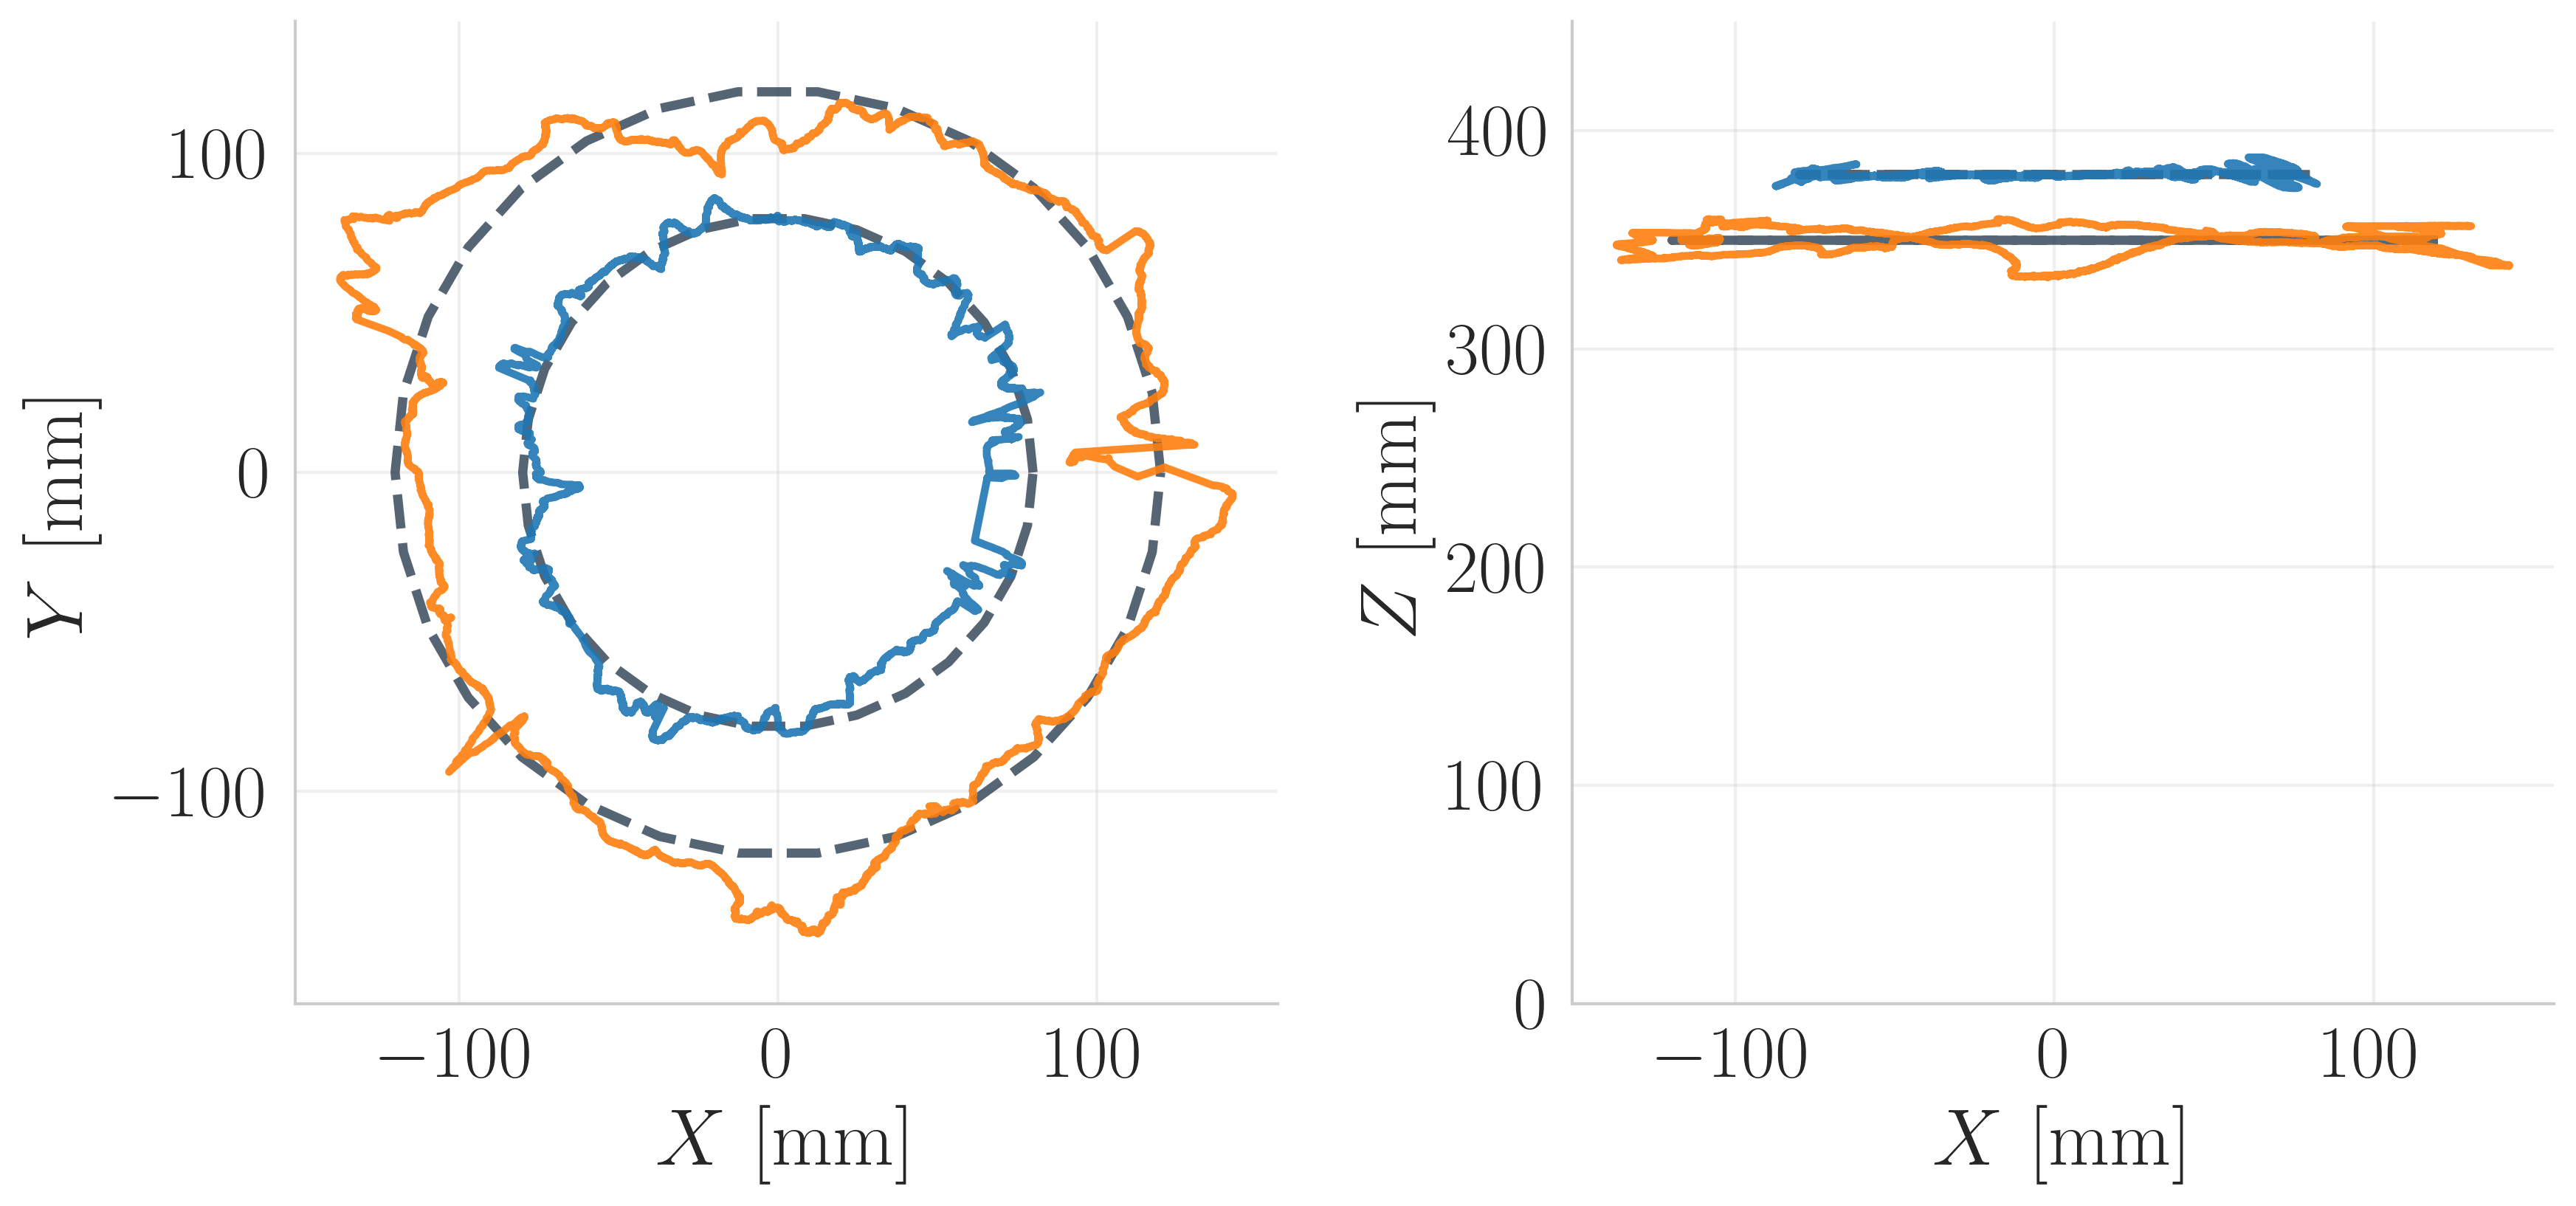

Plotted 2 configurations for Circle - jacobian control + W50g

--- Angular Error Analysis for Circle - jacobian control + W50g ---
r=80mm, h=380mm: 26.50 ± 0.25 $^\circ$
r=120mm, h=350mm: 46.21 ± 1.26 $^\circ$


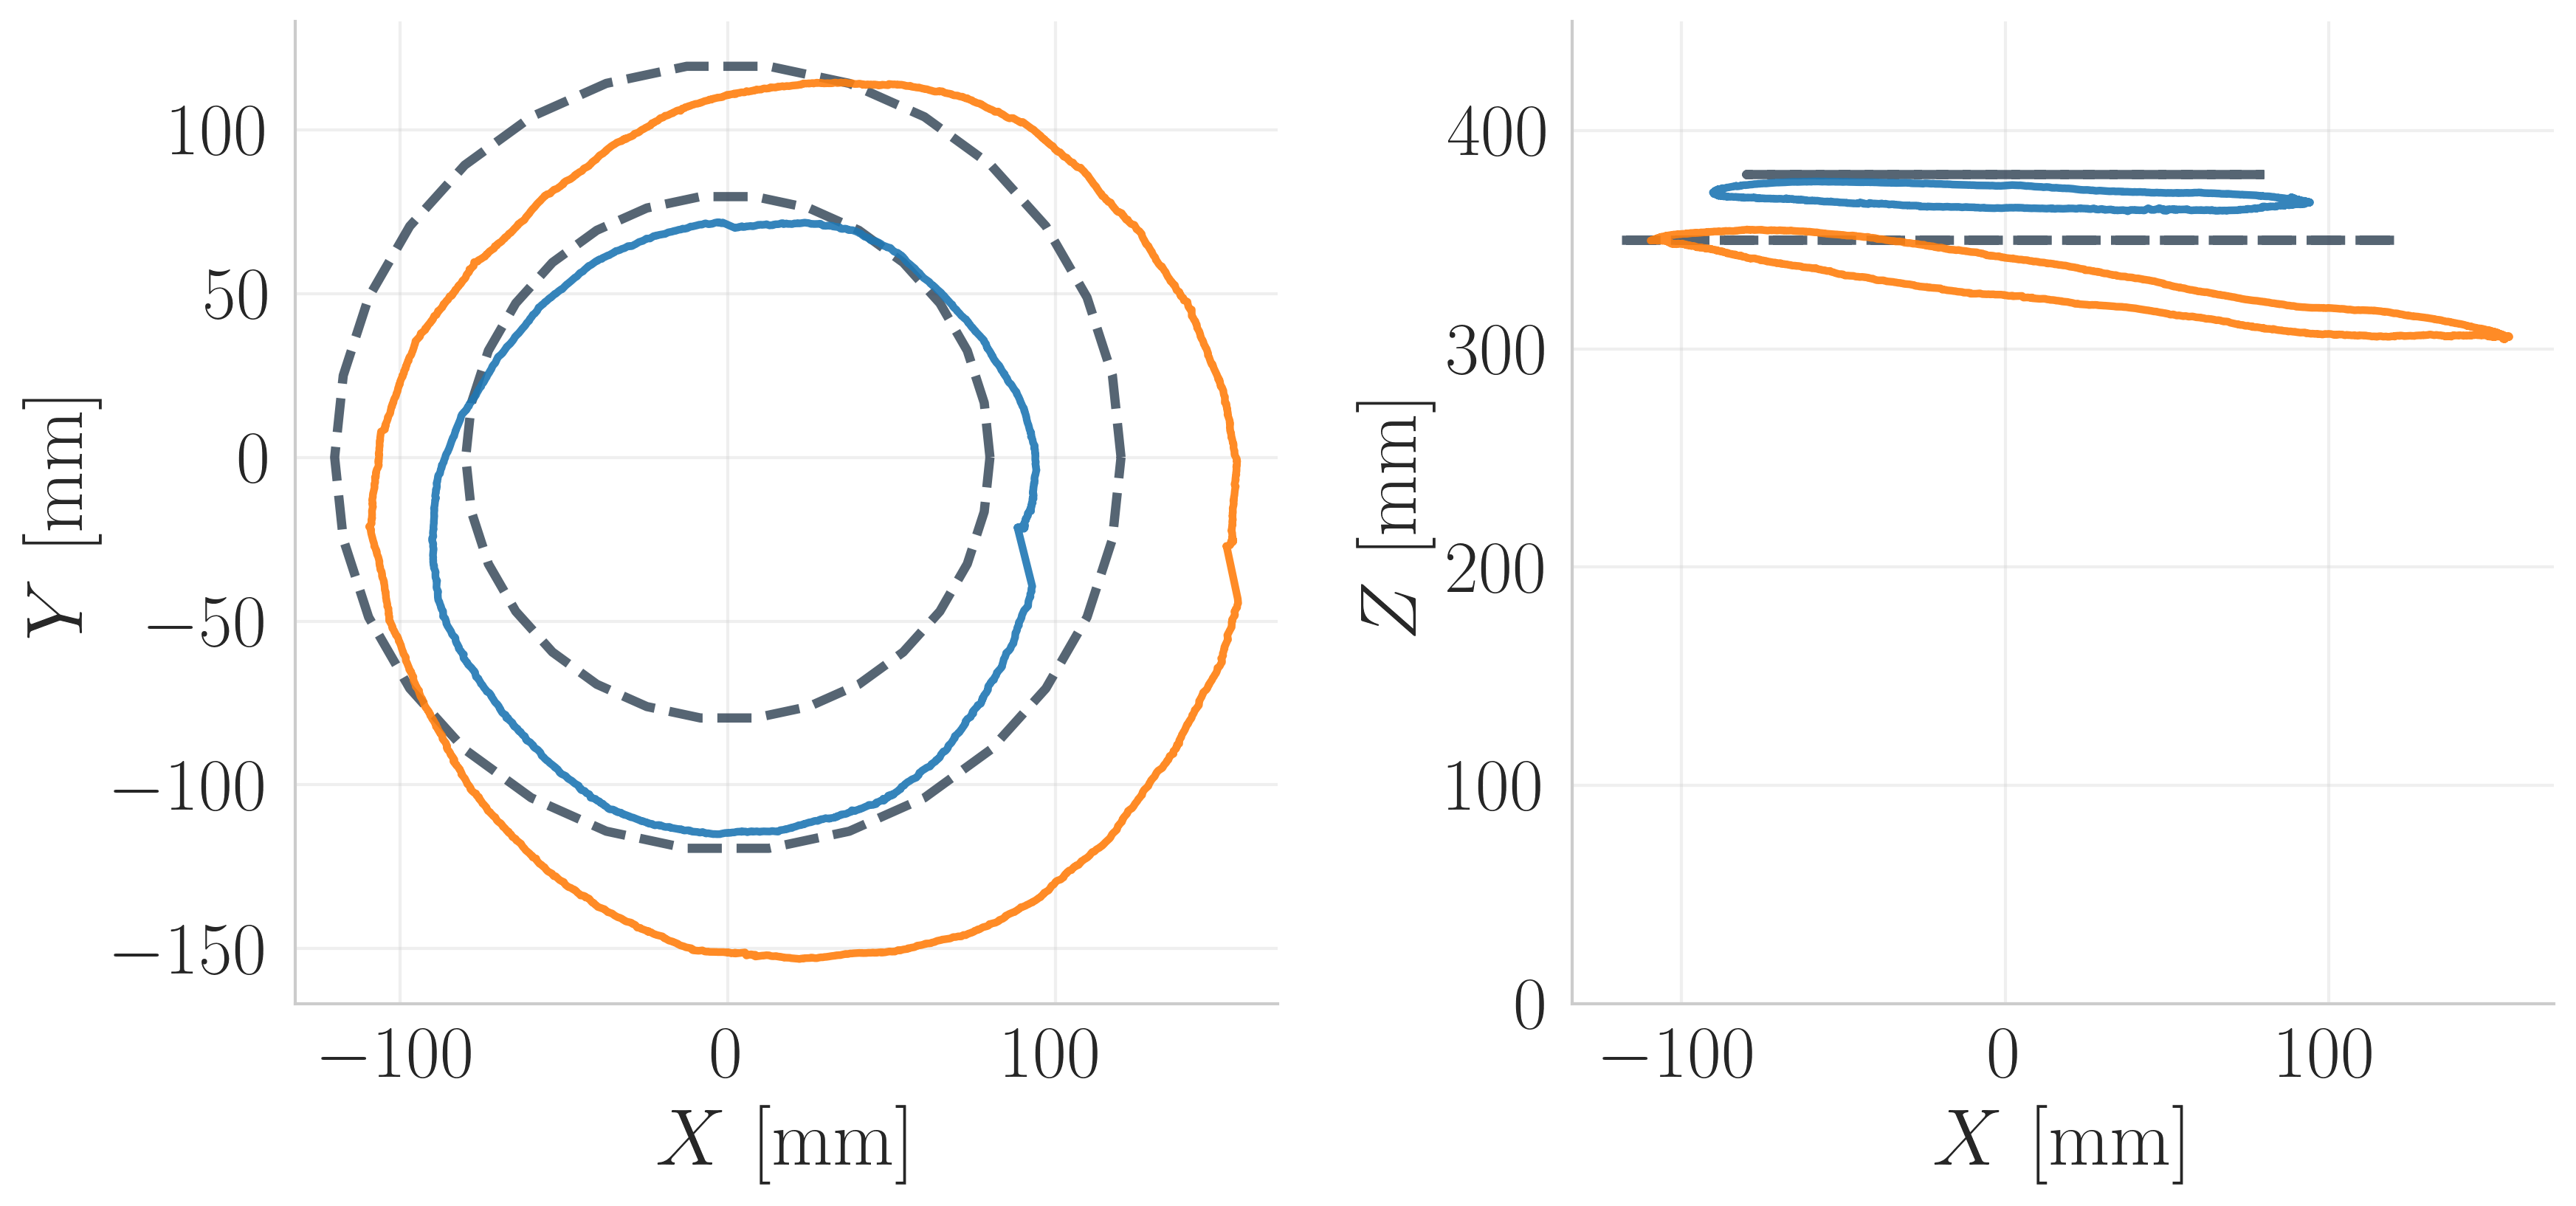

Plotted 2 configurations for Circle - jacobian control + W50g

--- Angular Error Analysis for Circle - jacobian control + W50g - Open Loop ---
r=80mm, h=380mm: 38.02 ± 0.60 $^\circ$
r=120mm, h=350mm: 74.40 ± 0.63 $^\circ$


In [19]:
# Measured final perturbation weight
w_string = "W50g"

# Plotting results for the disturbed controller
print(f"\n{'='*60}")
print(f"PLOTTING RESULTS FOR WEIGHT: {w_string}")
print(f"{'='*60}")

# Circles
print(f"\n--- Circle Plots ({w_string}) ---")

# CL jacobian
ClosedLoopPolygonPlotting("jacobian", 30, w_string=w_string)

# OL jacobian
OpenLoopPolygonPlotting("jacobian", 30, w_string=w_string)

Controller performances

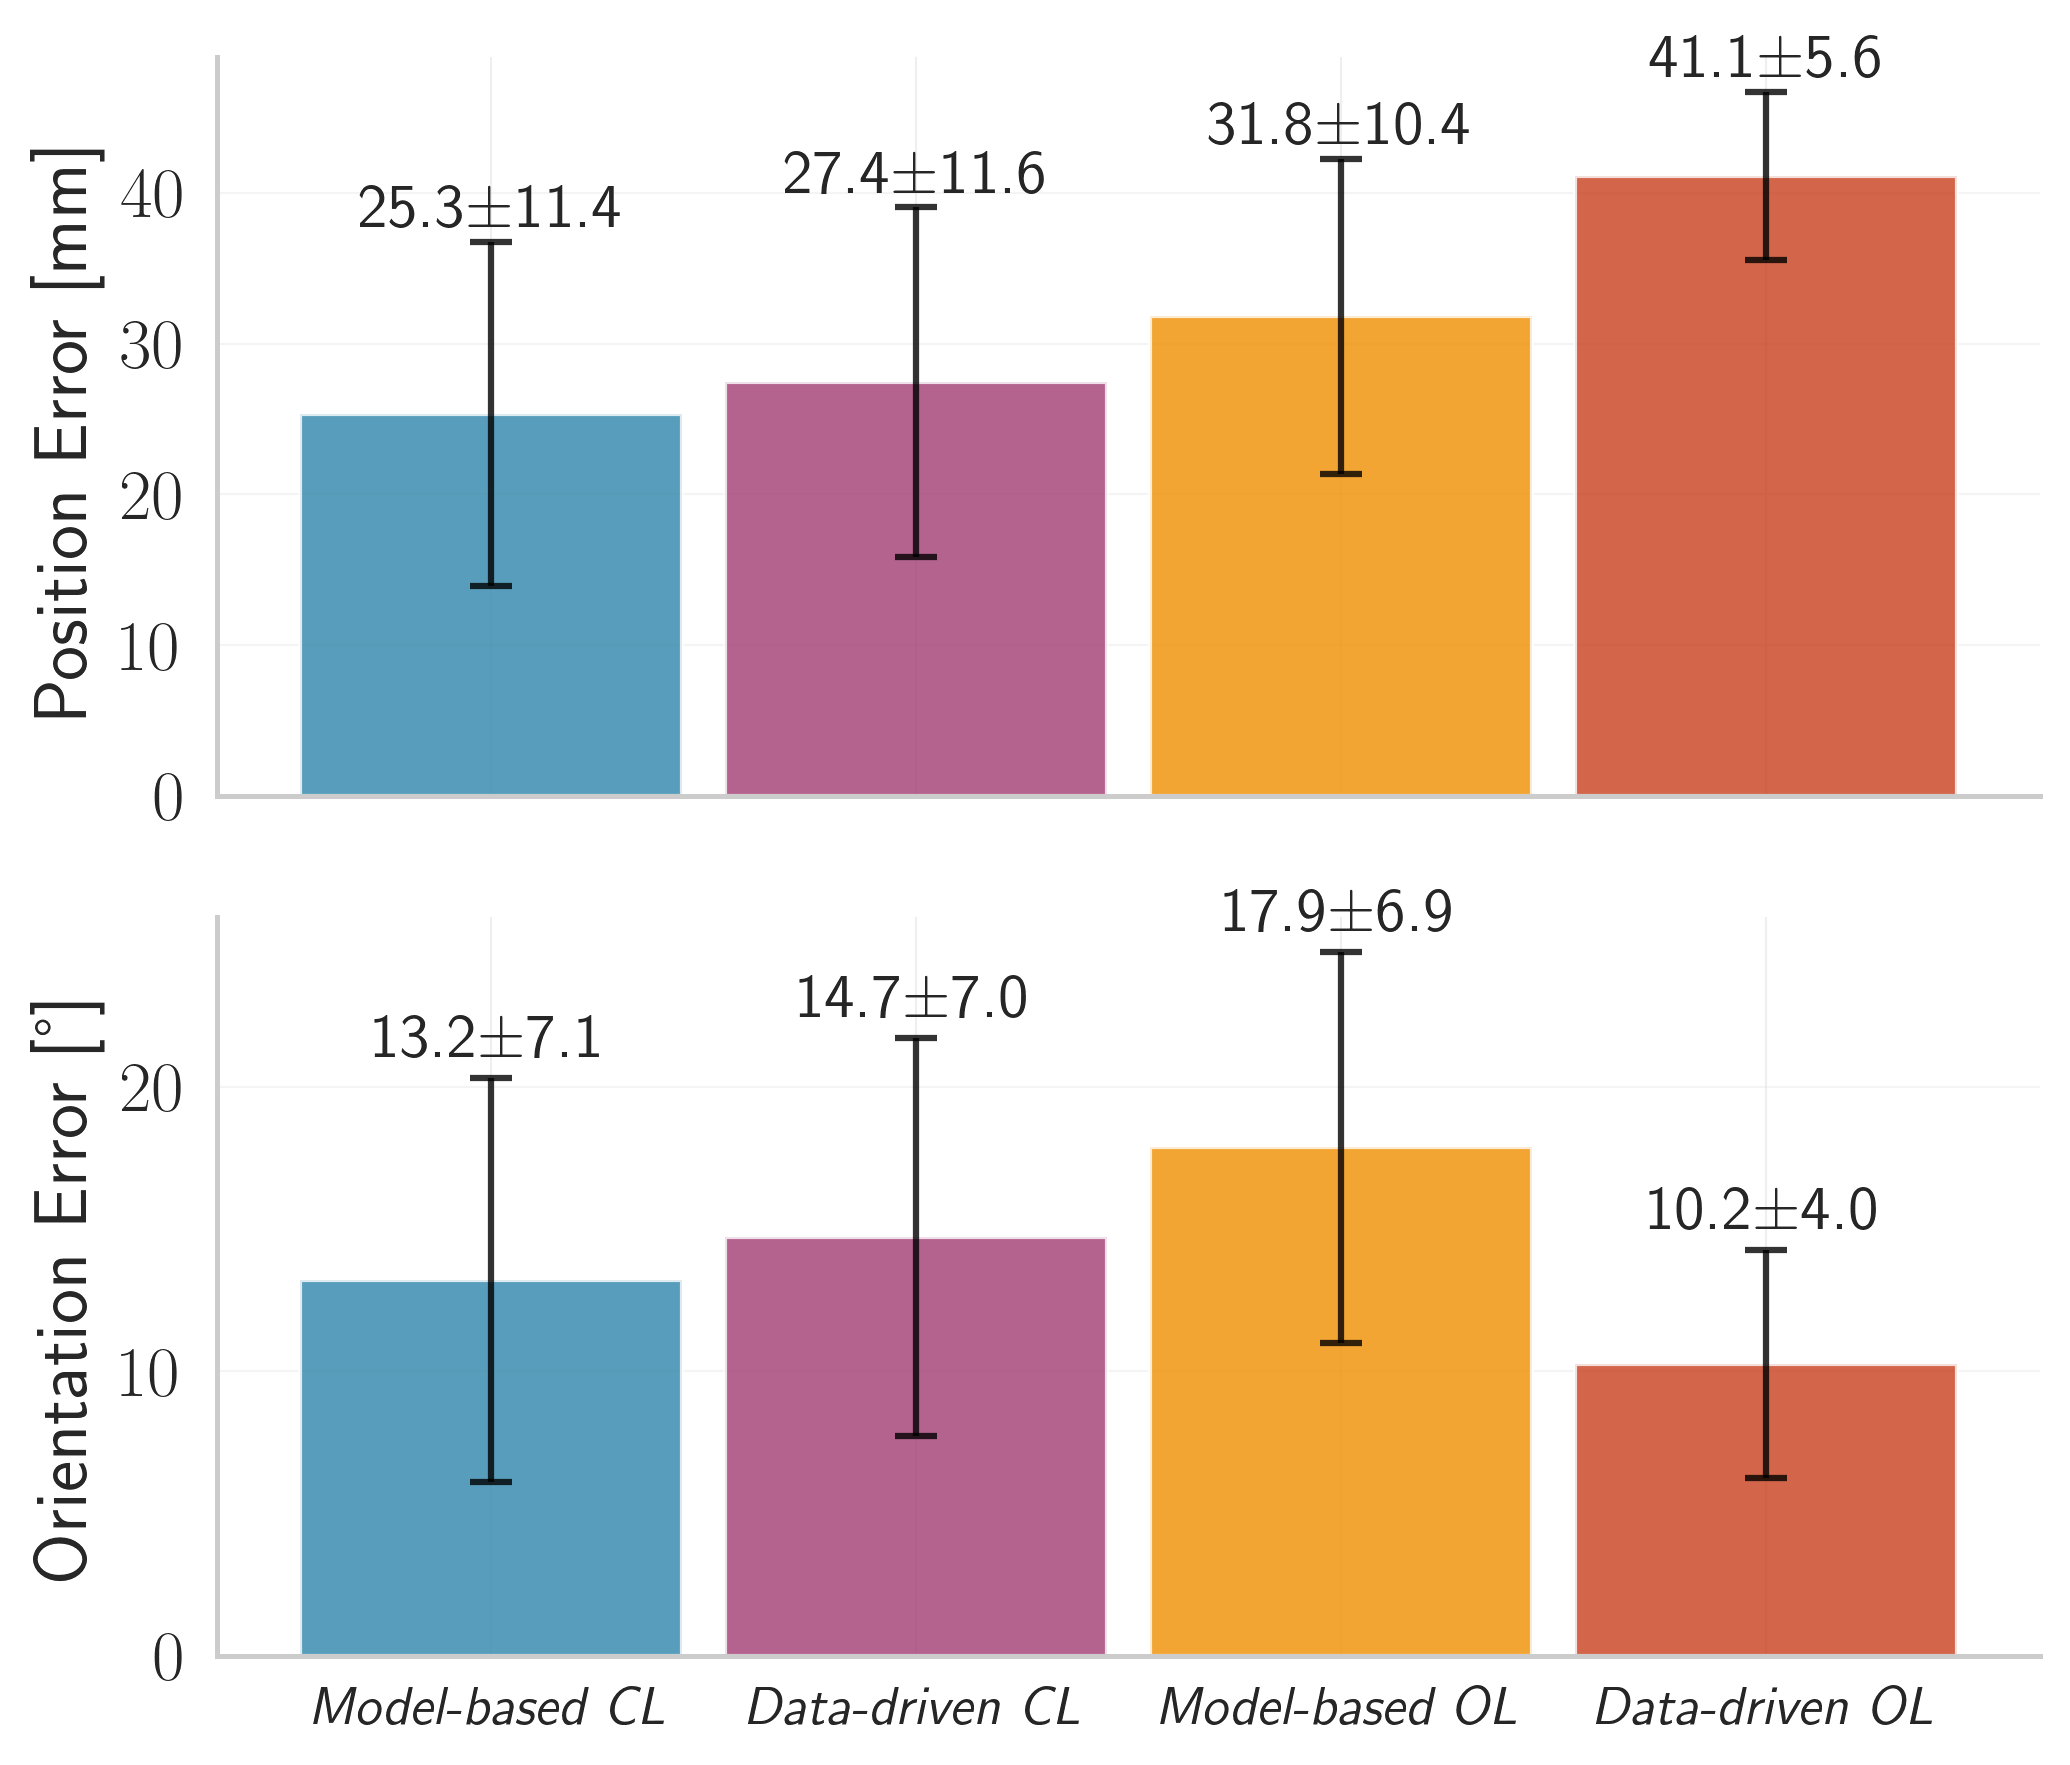

In [20]:
position_means = [25.32, 27.42, 31.81, 41.11]
position_stds = [11.42, 11.60, 10.43, 5.57]
orientation_means = [13.21, 14.72, 17.87, 10.25]
orientation_stds = [7.10, 7.00, 6.87, 4.01]

labels = [r'\textit{Model-based CL}',
          r'\textit{Data-driven CL}',
          r'\textit{Model-based OL}',
          r'\textit{Data-driven OL}']

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6))

x_pos = np.arange(len(labels))
bar_width = 0.9

# Position subplot
bars1 = ax1.bar(x_pos, position_means, bar_width, yerr=position_stds, 
                color=colors, alpha=0.8, capsize=5,
                error_kw={'elinewidth': 1.5, 'capthick': 1.5, 'alpha': 0.8})

for i, (bar, mean, std) in enumerate(zip(bars1, position_means, position_stds)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.5,
             f'{mean:.1f}$\pm${std:.1f}',
             ha='center', va='bottom', fontsize=15, fontweight='bold')

ax1.set_ylabel(r'\text{Position Error [mm]}', fontsize=18, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([])
ax1.yaxis.set_major_locator(plt.MultipleLocator(10))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax1.grid(True, axis='y', which='major', linestyle='-', alpha=0.2, linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)
ax1.set_ylim(bottom=0)
ax1.tick_params(axis='y', labelsize=17)

# Orientation subplot
bars2 = ax2.bar(x_pos, orientation_means, bar_width, yerr=orientation_stds, 
                color=colors, alpha=0.8, capsize=5,
                error_kw={'elinewidth': 1.5, 'capthick': 1.5, 'alpha': 0.8})

for i, (bar, mean, std) in enumerate(zip(bars2, orientation_means, orientation_stds)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + std + 0.5,
             f'{mean:.1f}$\pm${std:.1f}',
             ha='center', va='bottom', fontsize=15, fontweight='bold')

ax2.set_ylabel(r'\text{Orientation Error [°]}', fontsize=18, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=13)
ax2.yaxis.set_major_locator(plt.MultipleLocator(10))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax2.grid(True, axis='y', which='major', linestyle='-', alpha=0.2, linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis='y', labelsize=17)

plt.tight_layout()
plt.show()